# 🏥 Personalized Healthcare Data Analysis for Clinical Insights

**Domain:** Healthcare  
**Difficulty:** Advanced  
**Type:** Exploratory Data Analysis (EDA) — No Machine Learning  

---

## 🎯 Objective

This notebook performs a **comprehensive exploratory data analysis** on a personalized healthcare dataset to:

- Understand the distribution and patterns of patient demographics, vitals, and clinical metrics
- Identify key risk factors associated with heart disease and diabetes
- Examine how lifestyle choices (smoking, alcohol, physical activity, diet) impact health outcomes
- Explore the relationship between mental health scores and physical health indicators
- Investigate genetic marker influences on health risk
- Apply statistical tests to validate observed patterns

---

## 🏥 Healthcare Importance

Chronic diseases such as cardiovascular disease and diabetes account for a significant share of global morbidity and mortality. Understanding what drives risk — across lifestyle, genetics, and clinical parameters — is foundational to preventive medicine. This analysis extracts actionable insights from real-world-style patient data to support clinical decision-making.

---

## ❓ Key Questions

1. What demographic and clinical factors are most strongly associated with heart disease or diabetes risk?
2. How do lifestyle factors (smoking, diet, activity level) influence cholesterol, BMI, and blood pressure?
3. Is there a measurable relationship between mental health scores and physical health markers?
4. Do genetic variants (APOE e4, BRCA, cardiometabolic PRS) correspond to elevated risk scores?
5. Are there statistically significant differences in clinical markers across risk groups?

---
# 📦 Section 1: Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, f_oneway

# Display settings
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


---
# 📂 Section 2: Load Dataset

We load the dataset directly from Kaggle using `kagglehub`. Ensure you have your Kaggle credentials configured.

In [2]:
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

dataset_id = "nailasrivastava/personalised-healthcare-recommendation-system"
file_path = "personalised_dataset.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_id,
    file_path
)

print("First 5 rows:")
print(df.head())

print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

Using Colab cache for faster access to the 'personalised-healthcare-recommendation-system' dataset.
First 5 rows:
   Patient_ID  Age  Gender   BMI  Smoking_Status Alcohol_Consumption  \
0           1   55    Male 26.00  Current smoker                 NaN   
1           2   33    Male 29.50      Non-smoker                 Low   
2           3   62  Female 31.30      Non-smoker                 Low   
3           4   65    Male 19.00      Non-smoker                High   
4           5   19    Male 26.10      Non-smoker                 Low   

  Physical_Activity_Level   Diet_Type Blood_Pressure  Cholesterol  \
0          Lightly Active  Vegetarian         129/70       201.90   
1               Sedentary  Vegetarian         106/64       202.80   
2          Lightly Active        Keto         103/80       207.40   
3          Lightly Active  Vegetarian         121/69       179.60   
4       Moderately Active       Vegan         103/61       181.10   

   Glucose_Level  HbA1c Heart_Disease_

---
# 🔍 Section 3: Data Overview

In [3]:
# Basic shape and info
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n')
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Memory Usage ---')
print(df.memory_usage(deep=True).sum() / 1024, 'KB')

Dataset Shape: 2000 rows × 40 columns

--- Data Types ---
Patient_ID                    int64
Age                           int64
Gender                       object
BMI                         float64
Smoking_Status               object
Alcohol_Consumption          object
Physical_Activity_Level      object
Diet_Type                    object
Blood_Pressure               object
Cholesterol                 float64
Glucose_Level               float64
HbA1c                       float64
Heart_Disease_Risk           object
Diabetes_Risk                object
Health_Risk                  object
Predicted_Insurance_Cost    float64
Diet_Recommendation          object
Exercise_Recommendation      object
PRS_Cardiometabolic         float64
PRS_Type2Diabetes           float64
APOE_e4_Carrier               int64
BRCA_Pathogenic_Variant       int64
Family_History_CVD            int64
Family_History_T2D            int64
Stress_Level                float64
Depression_Score              int64
Anxiet

In [4]:
# Statistical summary for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_ID,2000.00,1000.50,577.49,1.00,500.75,1000.50,1500.25,2000.00
Age,2000.00,49.23,15.48,18.00,38.00,50.00,60.00,85.00
BMI,2000.00,27.17,5.09,16.00,23.80,26.90,30.50,50.30
Cholesterol,2000.00,197.23,34.67,83.60,174.88,198.15,219.20,328.40
Glucose_Level,2000.00,91.49,12.77,50.00,83.10,91.40,99.80,134.20
HbA1c,2000.00,5.07,0.63,3.50,4.60,5.10,5.50,7.10
Predicted_Insurance_Cost,2000.00,1343.07,750.81,331.80,598.19,1191.90,2018.10,3684.19
PRS_Cardiometabolic,2000.00,-0.01,1.00,-2.91,-0.69,-0.00,0.66,2.94
PRS_Type2Diabetes,2000.00,0.01,1.00,-3.00,-0.68,0.00,0.71,3.00
APOE_e4_Carrier,2000.00,0.14,0.35,0.00,0.00,0.00,0.00,1.00


In [5]:
# Categorical column value counts overview
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}\n')
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

Categorical columns (12): ['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Blood_Pressure', 'Heart_Disease_Risk', 'Diabetes_Risk', 'Health_Risk', 'Diet_Recommendation', 'Exercise_Recommendation', 'Sleep_Quality']

--- Gender ---
Gender
Male      1037
Female     963
Name: count, dtype: int64

--- Smoking_Status ---
Smoking_Status
Non-smoker        1141
Former smoker      450
Current smoker     409
Name: count, dtype: int64

--- Alcohol_Consumption ---
Alcohol_Consumption
Moderate    664
Low         551
High        315
Name: count, dtype: int64

--- Physical_Activity_Level ---
Physical_Activity_Level
Lightly Active       599
Moderately Active    598
Sedentary            526
Highly Active        277
Name: count, dtype: int64

--- Diet_Type ---
Diet_Type
Balanced         365
Vegan            346
Vegetarian       340
High Protein     323
Mediterranean    321
Keto             305
Name: count, dtype: int64

--- Blood_Pressure ---
Blood_Pressure
115/

---
# 🧹 Section 4: Data Cleaning

In [6]:
# 4.1 Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('✅ No missing values found.')
else:
    print(missing_df)

                     Missing Count  Missing %
Alcohol_Consumption            470      23.50


In [7]:
# 4.2 Check for duplicate rows
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'✅ Removed {dup_count} duplicate rows. New shape: {df.shape}')

Duplicate rows: 0


In [8]:
# 4.3 Handle Blood_Pressure column — split 'Systolic/Diastolic' string if needed
if 'Blood_Pressure' in df.columns:
    sample_val = df['Blood_Pressure'].dropna().iloc[0]
    print(f'Sample Blood_Pressure value: {sample_val}')

    if '/' in str(sample_val):
        bp_split = df['Blood_Pressure'].str.split('/', expand=True)
        df['Systolic_BP_parsed'] = pd.to_numeric(bp_split[0], errors='coerce')
        df['Diastolic_BP_parsed'] = pd.to_numeric(bp_split[1], errors='coerce')
        print('✅ Blood_Pressure split into Systolic_BP_parsed and Diastolic_BP_parsed')
    else:
        print('Blood_Pressure appears numeric or already split.')

# Use existing Systolic_BP / Diastolic_BP if already present
for col in ['Systolic_BP', 'Diastolic_BP']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('\nBlood pressure columns check done.')

Sample Blood_Pressure value: 129/70
✅ Blood_Pressure split into Systolic_BP_parsed and Diastolic_BP_parsed

Blood pressure columns check done.


In [9]:
# 4.4 Standardize categorical text columns (strip whitespace, title case)
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print('✅ Categorical columns standardized.')

✅ Categorical columns standardized.


In [10]:
# 4.5 Fill remaining missing values
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols_updated = df.select_dtypes(include='object').columns.tolist()
df[cat_cols_updated] = df[cat_cols_updated].fillna('Unknown')

print(f'✅ Missing values filled. Final shape: {df.shape}')

✅ Missing values filled. Final shape: (2000, 42)


---
# 📊 Section 5: Exploratory Data Analysis (EDA)

## 5.1 Univariate Analysis — Numeric Features

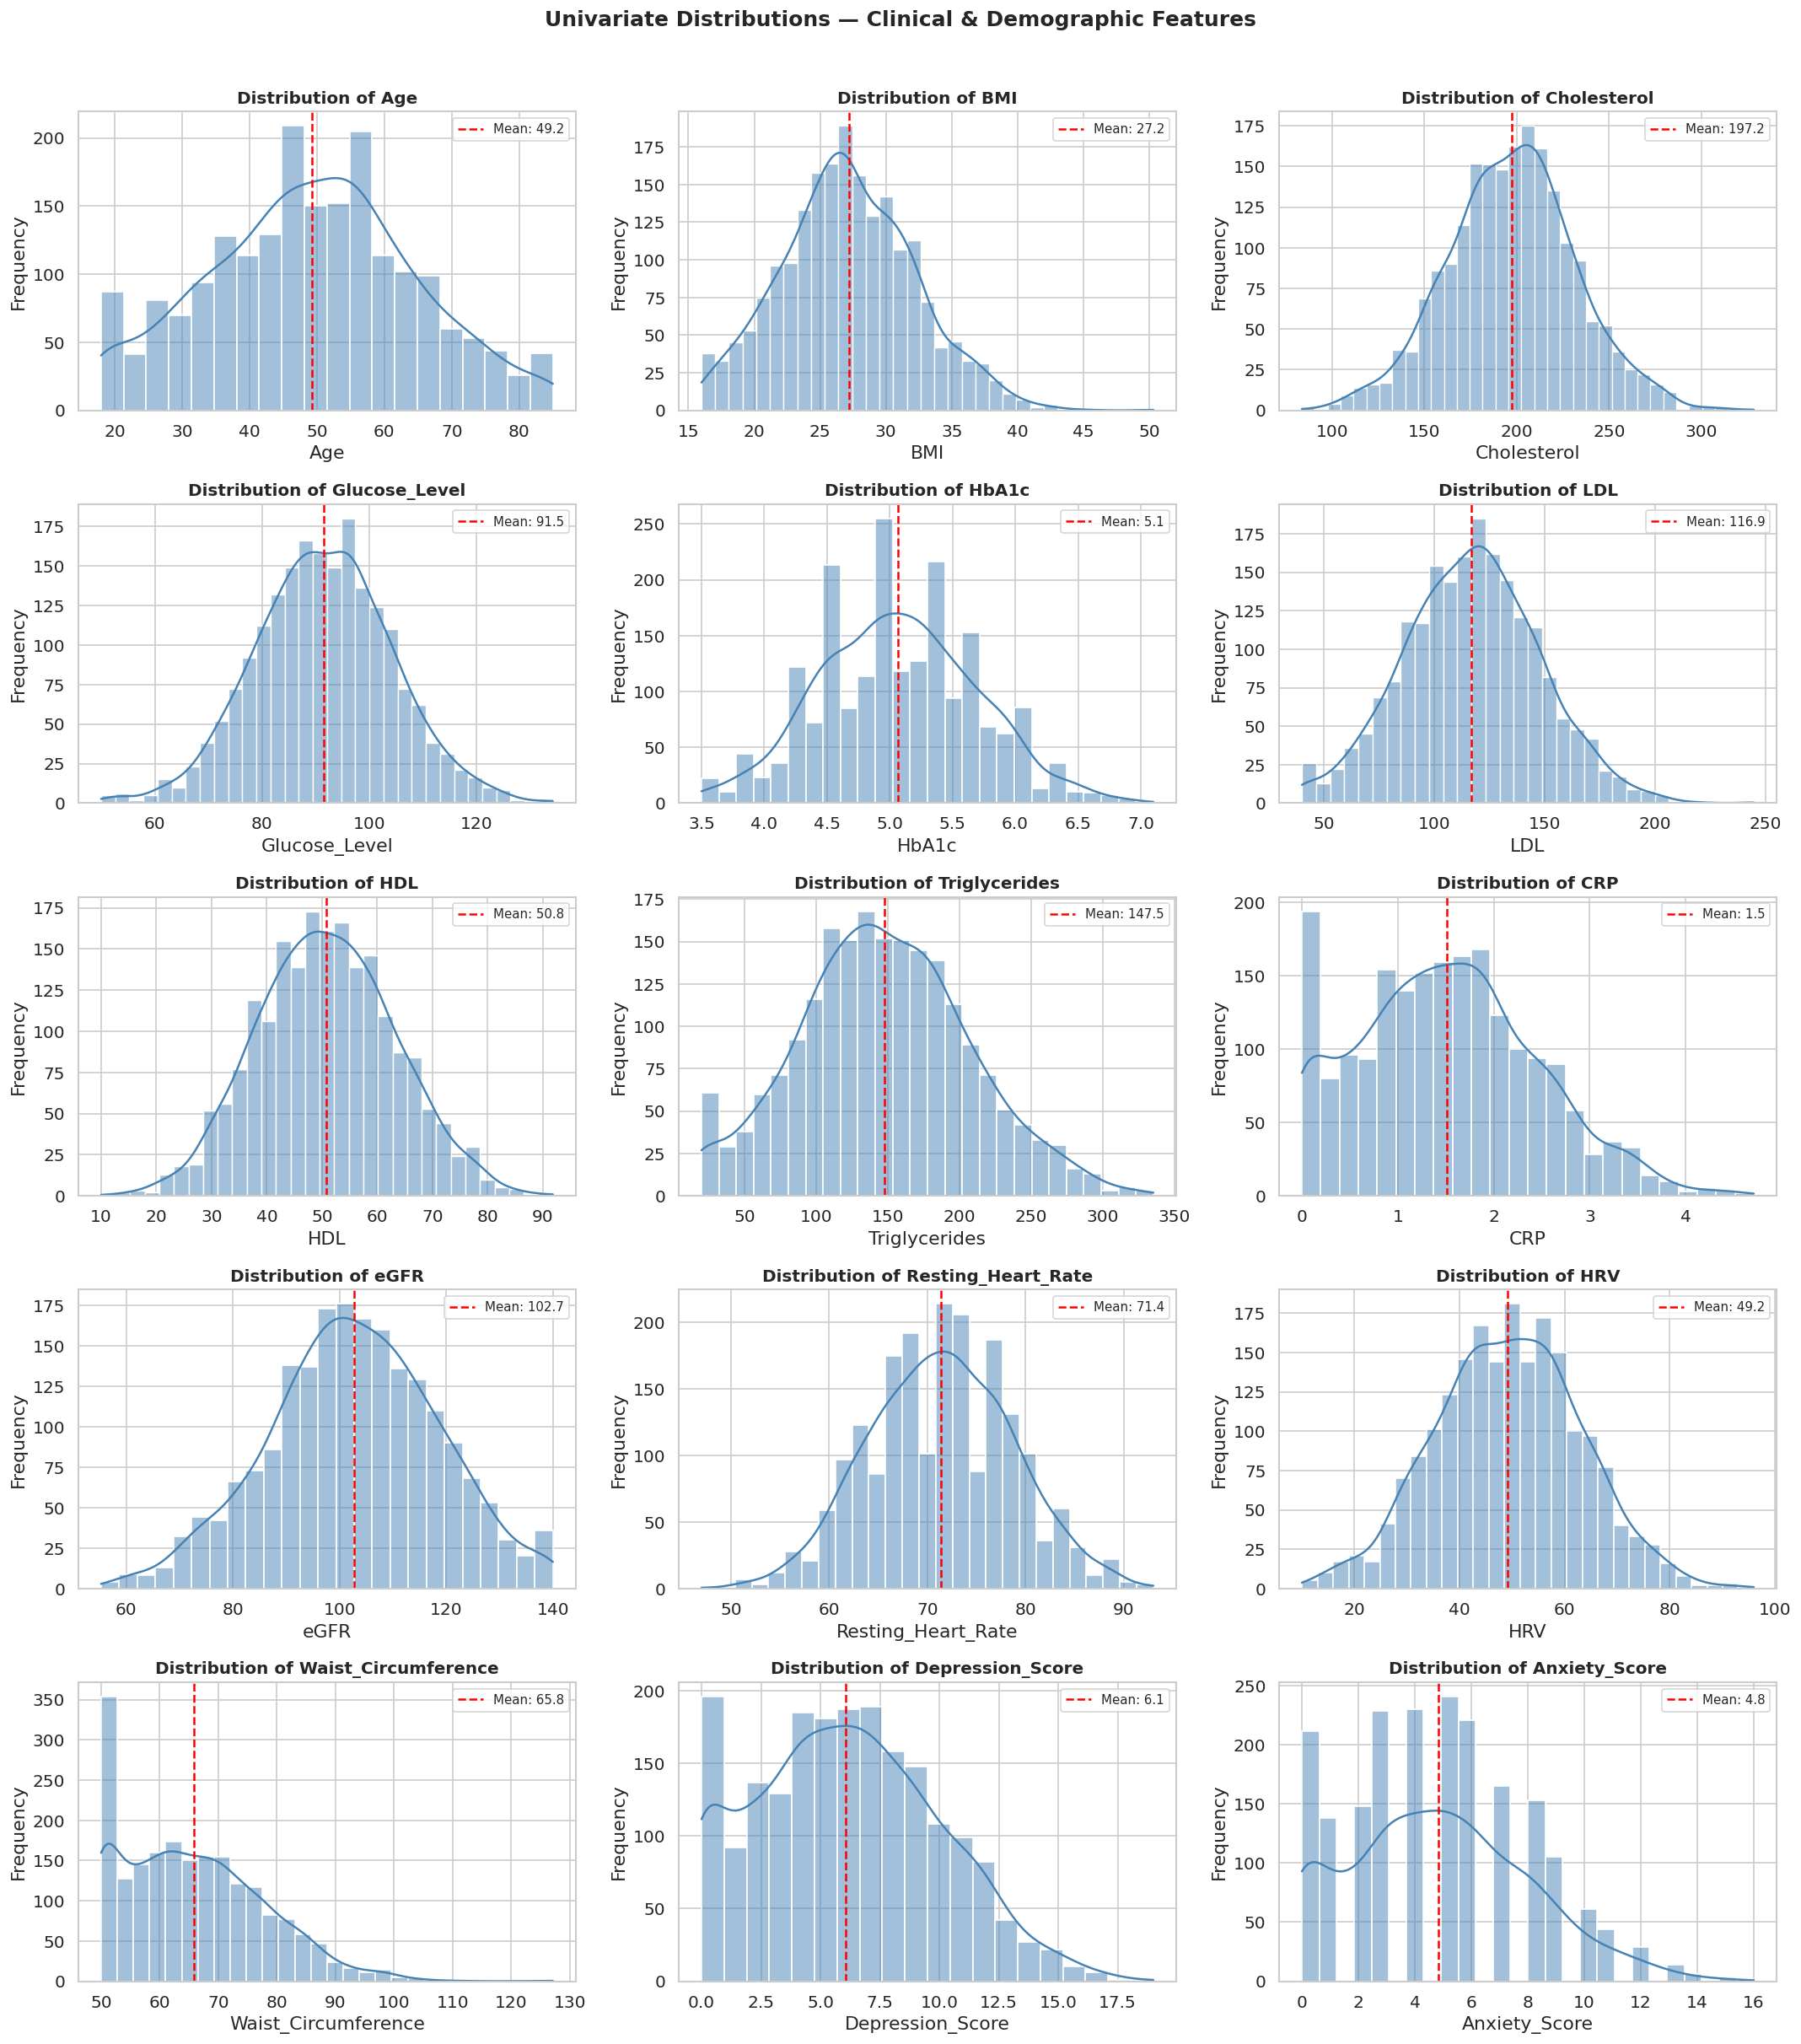

In [11]:
# Distribution of key numeric features
key_num_cols = ['Age', 'BMI', 'Cholesterol', 'Glucose_Level', 'HbA1c',
                'LDL', 'HDL', 'Triglycerides', 'CRP', 'eGFR',
                'Resting_Heart_Rate', 'HRV', 'Waist_Circumference',
                'Depression_Score', 'Anxiety_Score']

# Keep only those that exist
key_num_cols = [c for c in key_num_cols if c in df.columns]

n_cols = 3
n_rows = (len(key_num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=9)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions — Clinical & Demographic Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5.2 Univariate Analysis — Categorical Features

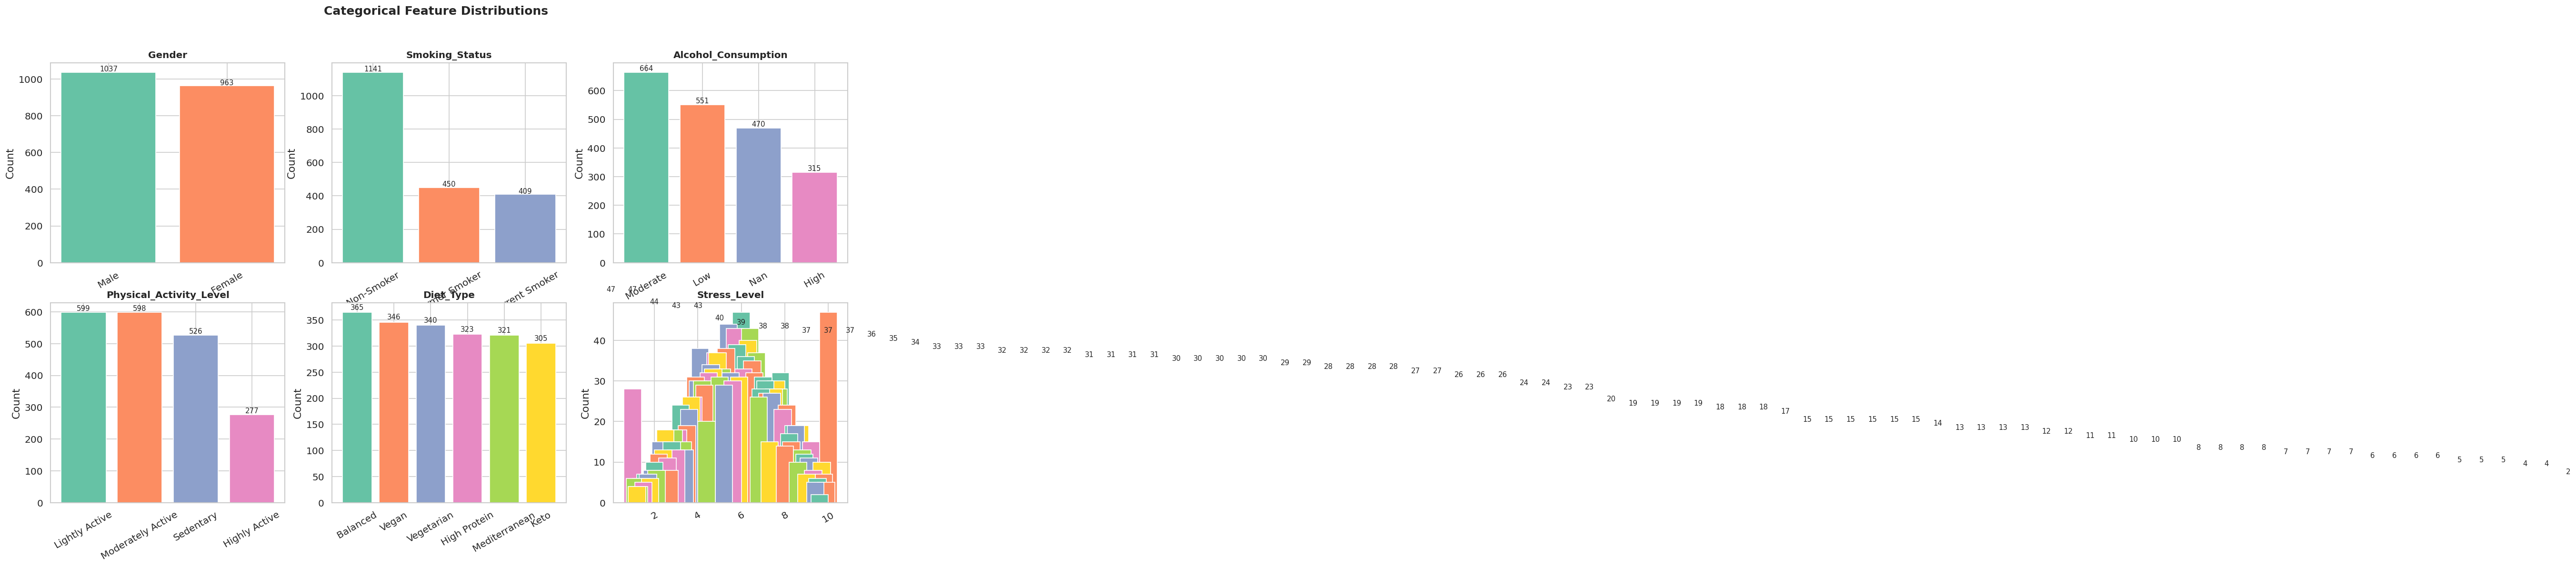

In [12]:
# Bar charts for key categorical variables
key_cat_cols = ['Gender', 'Smoking_Status', 'Alcohol_Consumption',
                'Physical_Activity_Level', 'Diet_Type', 'Stress_Level']
key_cat_cols = [c for c in key_cat_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

palette = sns.color_palette('Set2', 6)

for i, col in enumerate(key_cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=palette[:len(counts)], edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha='center', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.3 Bivariate Analysis — Risk Factors vs. Health Risk

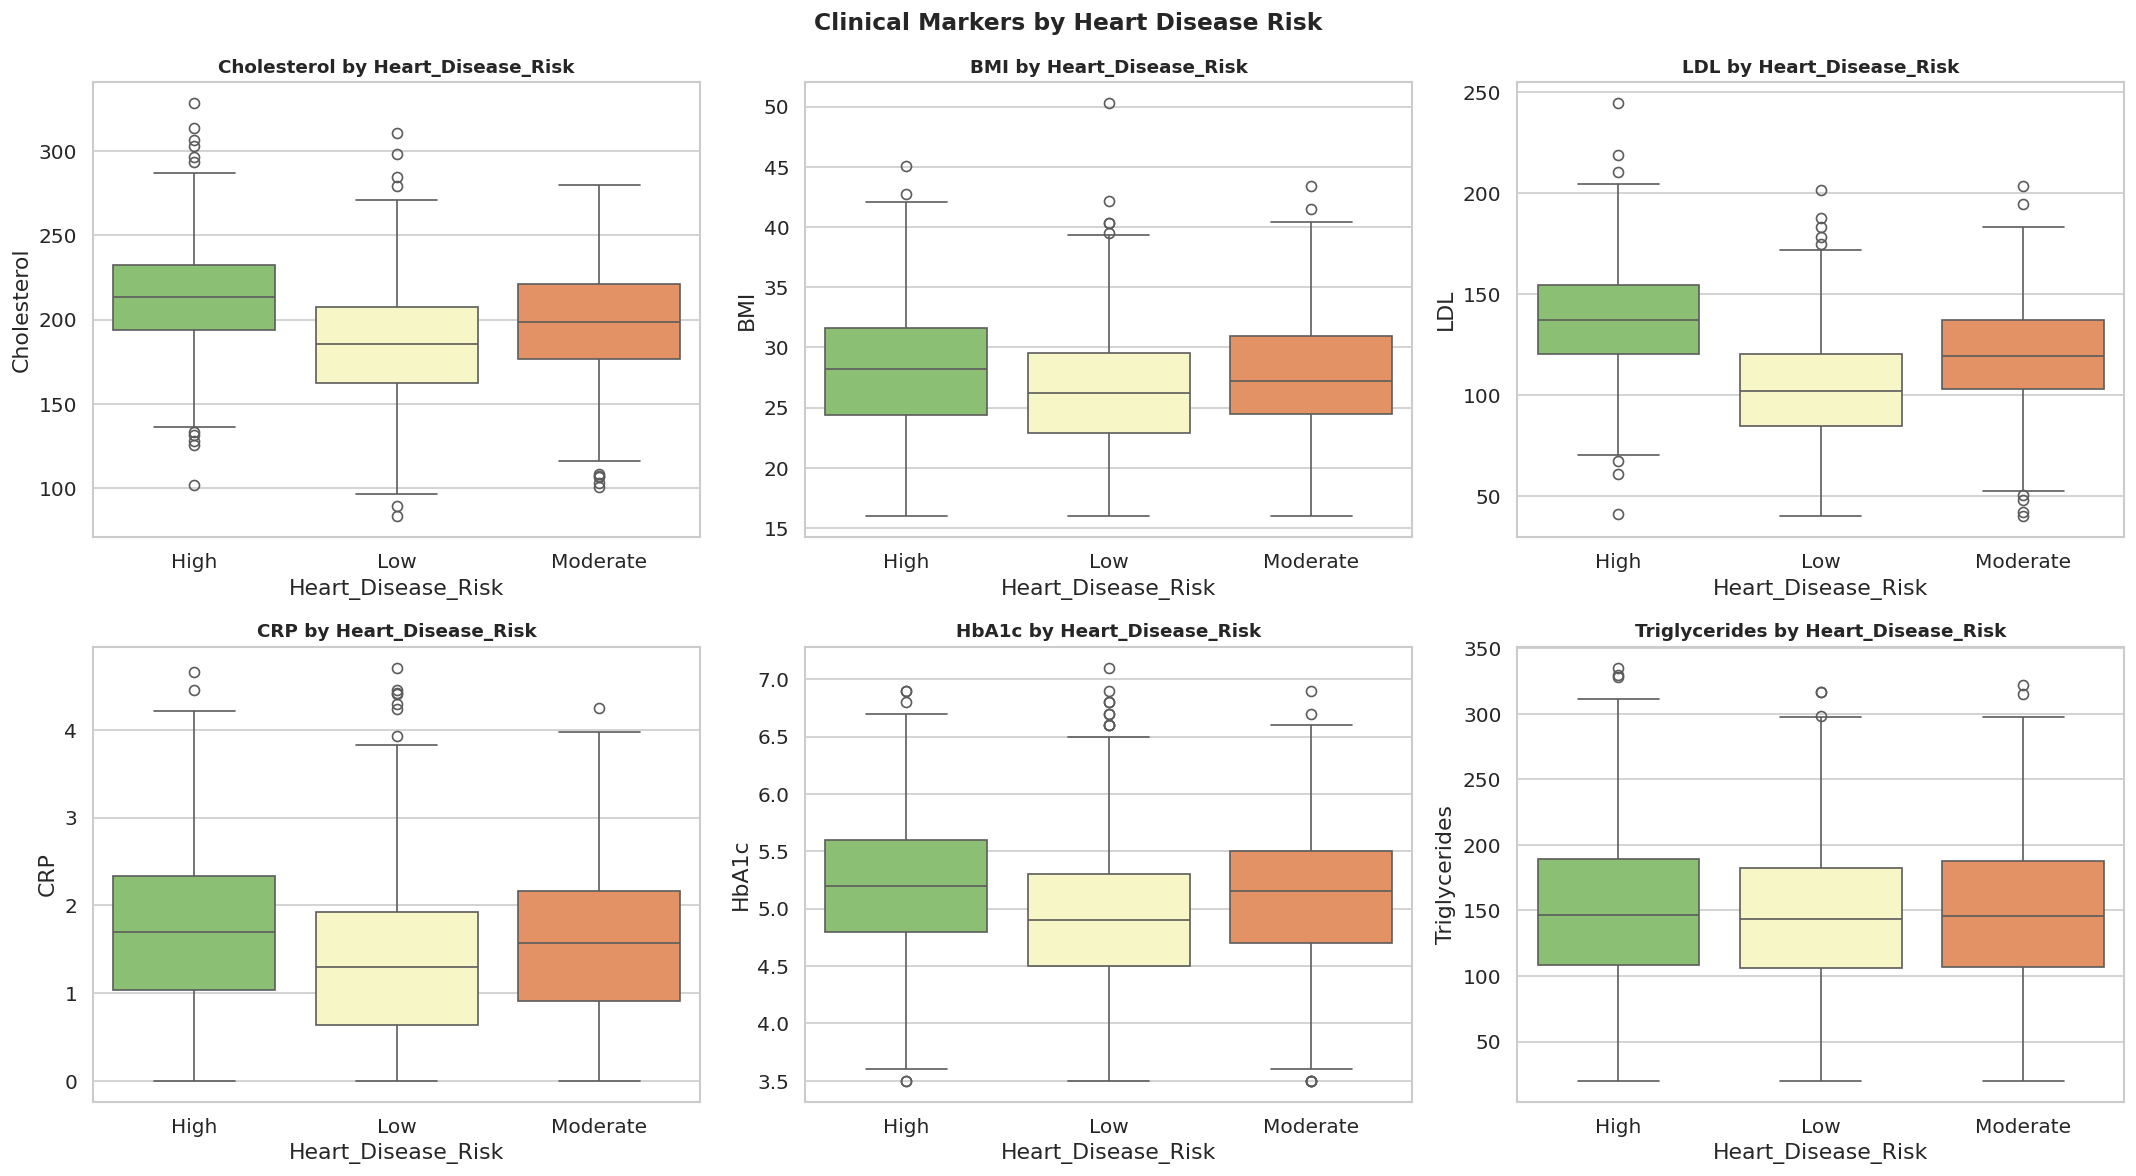

In [13]:
# Boxplots: Clinical markers by Heart_Disease_Risk
if 'Heart_Disease_Risk' in df.columns:
    risk_col = 'Heart_Disease_Risk'
    clinical = ['Cholesterol', 'BMI', 'LDL', 'CRP', 'HbA1c', 'Triglycerides']
    clinical = [c for c in clinical if c in df.columns]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, col in enumerate(clinical):
        sns.boxplot(data=df, x=risk_col, y=col, ax=axes[i],
                    palette='RdYlGn_r', order=sorted(df[risk_col].unique()))
        axes[i].set_title(f'{col} by {risk_col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(risk_col)
        axes[i].set_ylabel(col)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Clinical Markers by Heart Disease Risk', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

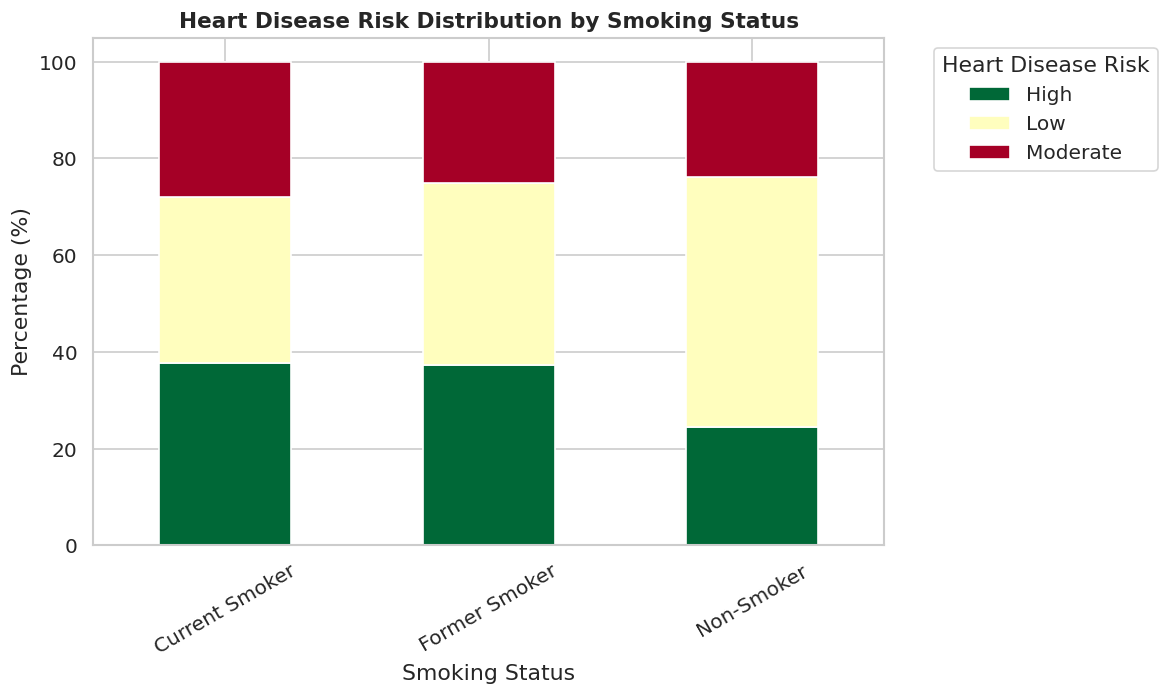

In [14]:
# Smoking vs Heart Disease Risk — Stacked bar chart
if all(c in df.columns for c in ['Smoking_Status', 'Heart_Disease_Risk']):
    ct = pd.crosstab(df['Smoking_Status'], df['Heart_Disease_Risk'], normalize='index') * 100

    ct.plot(kind='bar', stacked=True, figsize=(10, 6),
            colormap='RdYlGn_r', edgecolor='white')
    plt.title('Heart Disease Risk Distribution by Smoking Status', fontsize=13, fontweight='bold')
    plt.xlabel('Smoking Status')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=30)
    plt.legend(title='Heart Disease Risk', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

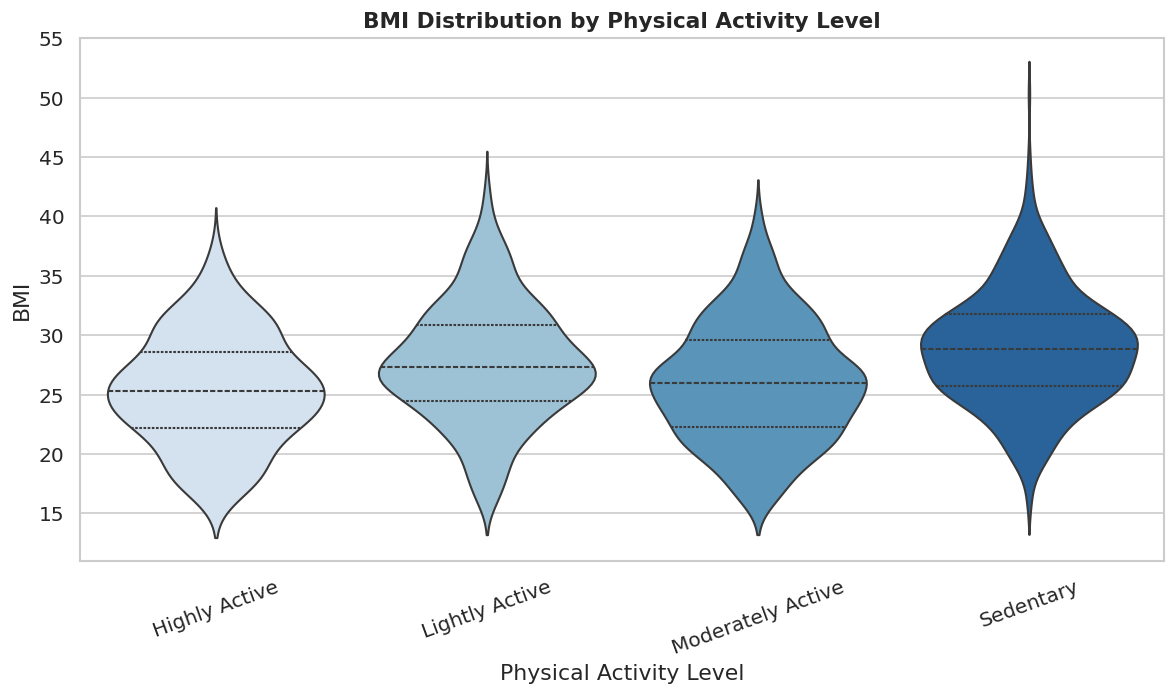

In [15]:
# Physical Activity vs BMI — Violin plot
if all(c in df.columns for c in ['Physical_Activity_Level', 'BMI']):
    fig, ax = plt.subplots(figsize=(10, 6))
    order = sorted(df['Physical_Activity_Level'].unique())
    sns.violinplot(data=df, x='Physical_Activity_Level', y='BMI', order=order,
                   palette='Blues', inner='quartile', ax=ax)
    ax.set_title('BMI Distribution by Physical Activity Level', fontsize=13, fontweight='bold')
    ax.set_xlabel('Physical Activity Level')
    ax.set_ylabel('BMI')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

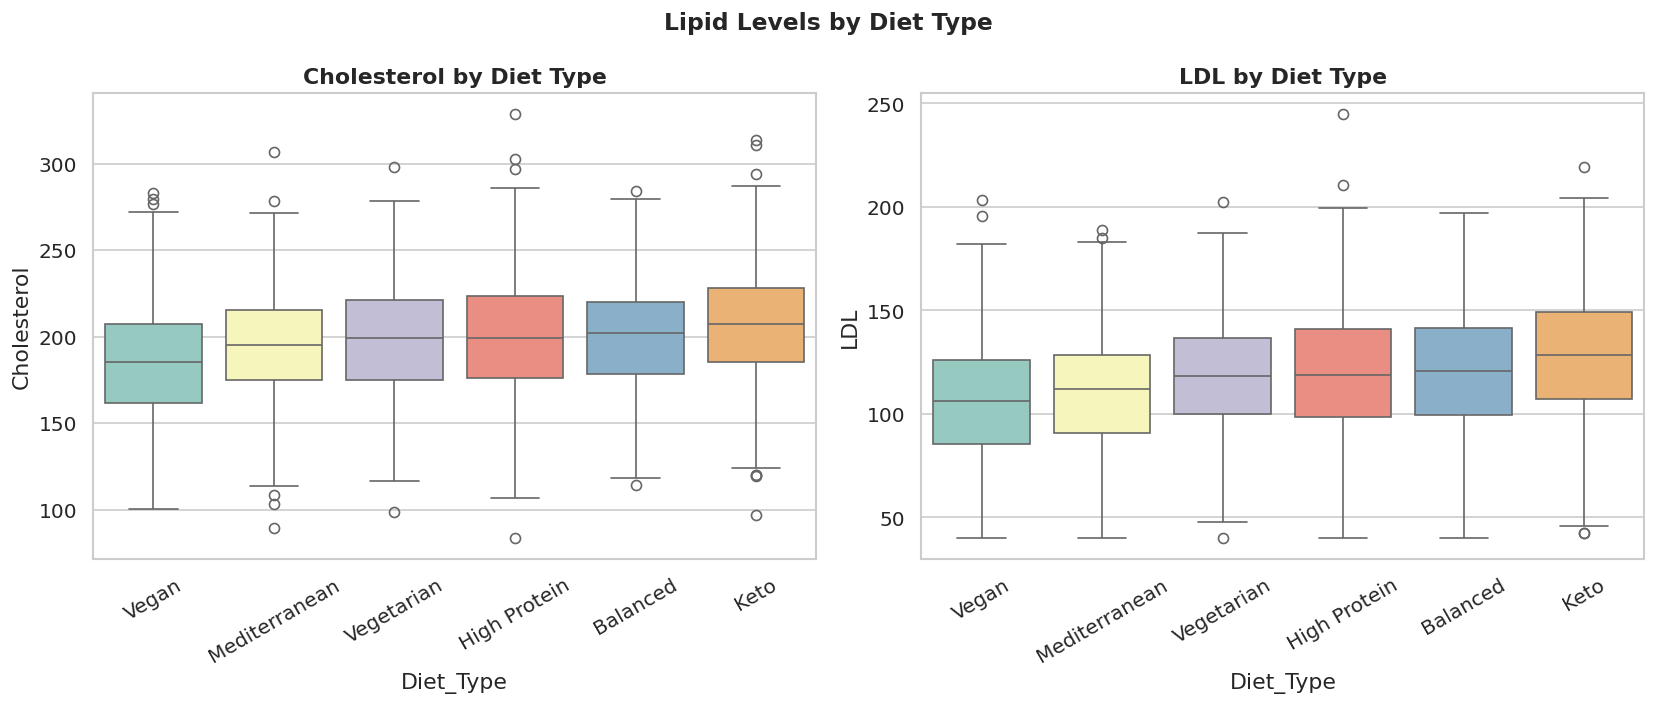

In [16]:
# Diet Type vs Cholesterol and LDL
if 'Diet_Type' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    order = df.groupby('Diet_Type')['Cholesterol'].median().sort_values().index if 'Cholesterol' in df.columns else None

    if 'Cholesterol' in df.columns:
        sns.boxplot(data=df, x='Diet_Type', y='Cholesterol', order=order,
                    palette='Set3', ax=axes[0])
        axes[0].set_title('Cholesterol by Diet Type', fontweight='bold')
        axes[0].tick_params(axis='x', rotation=30)

    if 'LDL' in df.columns:
        sns.boxplot(data=df, x='Diet_Type', y='LDL', order=order,
                    palette='Set3', ax=axes[1])
        axes[1].set_title('LDL by Diet Type', fontweight='bold')
        axes[1].tick_params(axis='x', rotation=30)

    plt.suptitle('Lipid Levels by Diet Type', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5.4 Bivariate Analysis — Age & Demographics

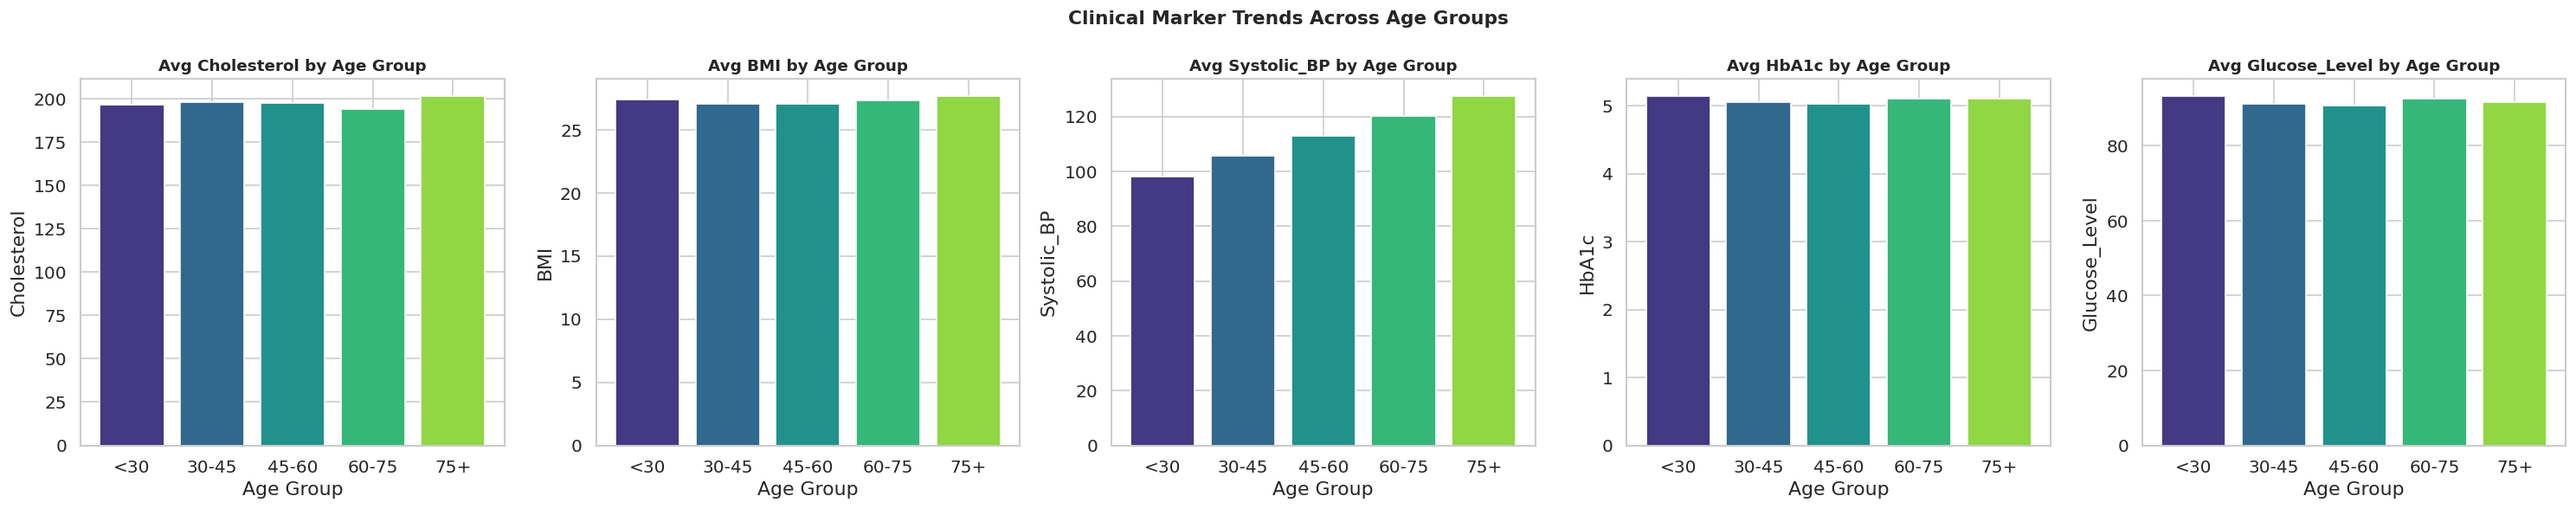

In [17]:
# Create Age Groups for analysis
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 30, 45, 60, 75, 100],
                          labels=['<30', '30-45', '45-60', '60-75', '75+'])

# Clinical markers trend by age group
age_markers = ['Cholesterol', 'BMI', 'Systolic_BP', 'HbA1c', 'Glucose_Level']
age_markers = [c for c in age_markers if c in df.columns]

age_group_means = df.groupby('Age_Group', observed=True)[age_markers].mean()

fig, axes = plt.subplots(1, len(age_markers), figsize=(5 * len(age_markers), 5))
if len(age_markers) == 1:
    axes = [axes]

colors = sns.color_palette('viridis', len(age_group_means))

for i, col in enumerate(age_markers):
    axes[i].bar(age_group_means.index.astype(str), age_group_means[col], color=colors, edgecolor='white')
    axes[i].set_title(f'Avg {col} by Age Group', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Age Group')
    axes[i].set_ylabel(col)

plt.suptitle('Clinical Marker Trends Across Age Groups', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

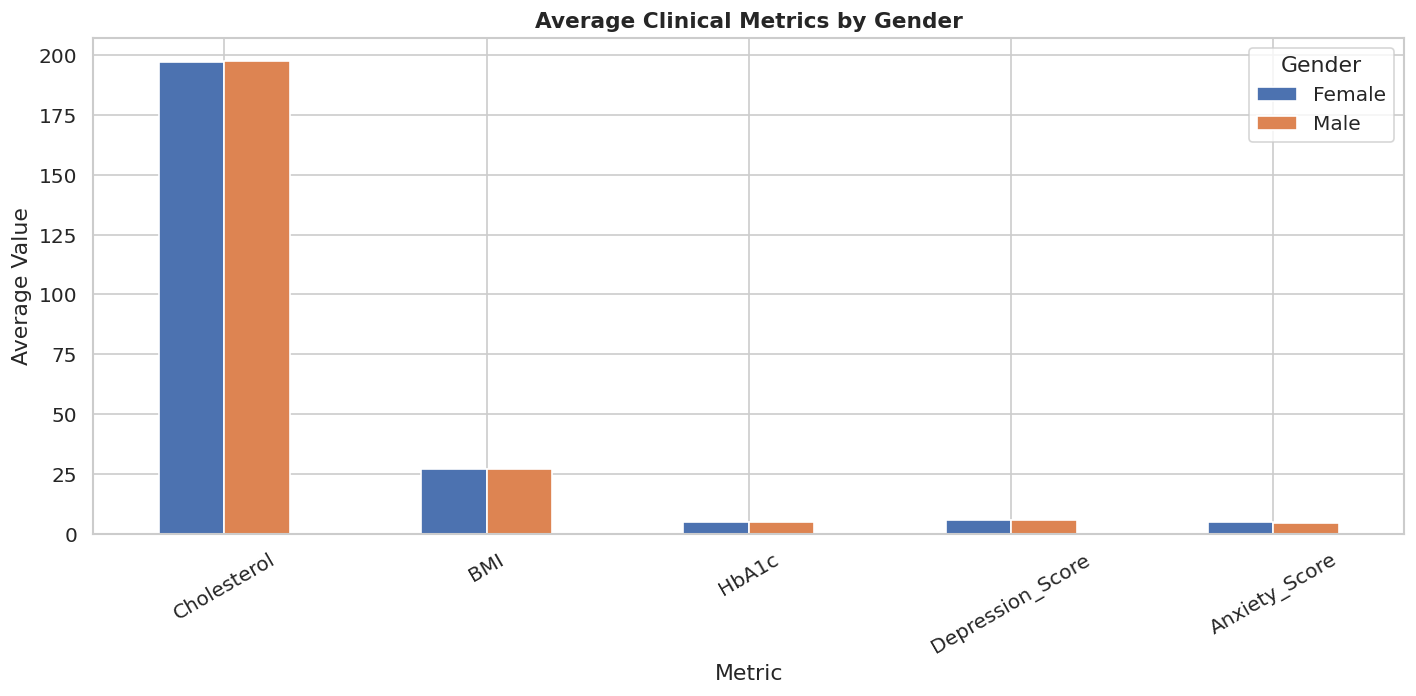

In [18]:
# Gender comparison for key health metrics
if 'Gender' in df.columns:
    gender_metrics = ['Cholesterol', 'BMI', 'HbA1c', 'Depression_Score', 'Anxiety_Score']
    gender_metrics = [c for c in gender_metrics if c in df.columns]

    gender_means = df.groupby('Gender')[gender_metrics].mean().T

    gender_means.plot(kind='bar', figsize=(12, 6), color=['#4C72B0', '#DD8452'],
                      edgecolor='white')
    plt.title('Average Clinical Metrics by Gender', fontsize=13, fontweight='bold')
    plt.xlabel('Metric')
    plt.ylabel('Average Value')
    plt.xticks(rotation=30)
    plt.legend(title='Gender')
    plt.tight_layout()
    plt.show()

## 5.5 Scatter Plots — Continuous Relationships

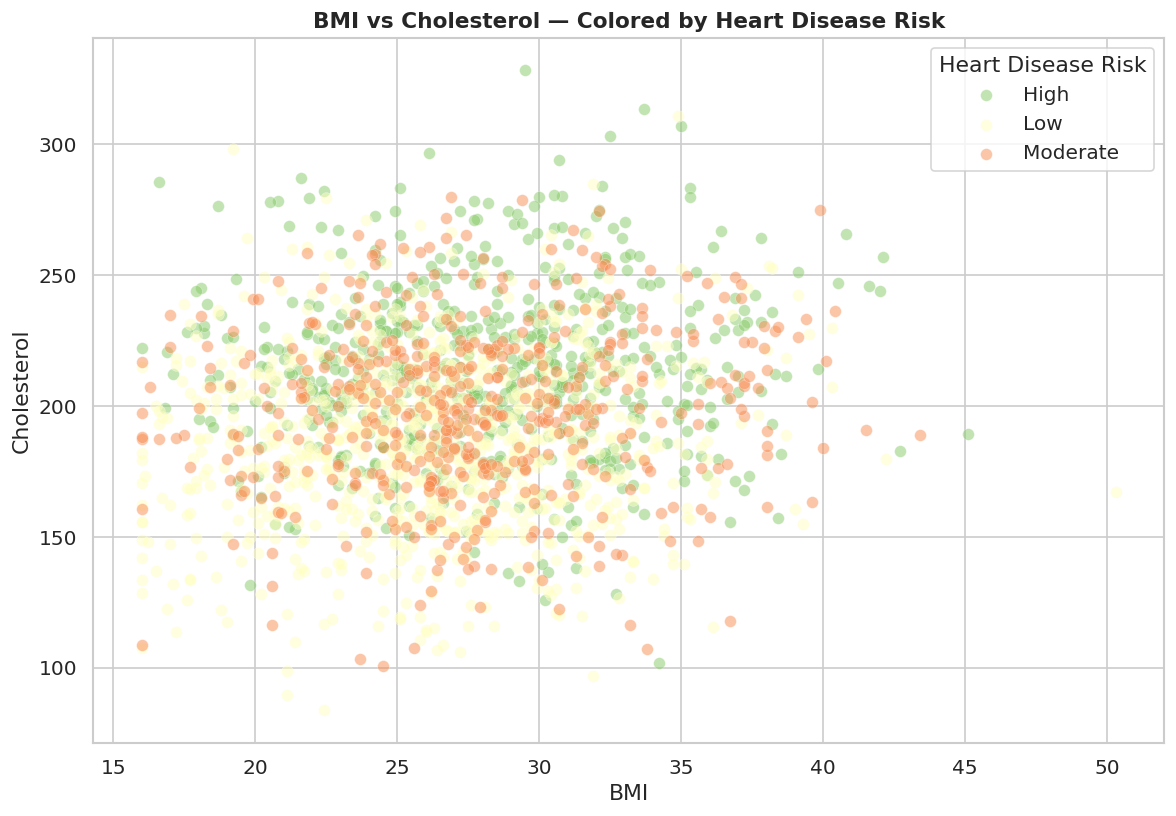

In [19]:
# Scatter: BMI vs Cholesterol, colored by Heart Disease Risk
if all(c in df.columns for c in ['BMI', 'Cholesterol', 'Heart_Disease_Risk']):
    fig, ax = plt.subplots(figsize=(10, 7))
    risk_levels = df['Heart_Disease_Risk'].unique()
    palette = sns.color_palette('RdYlGn_r', len(risk_levels))

    for idx, level in enumerate(sorted(risk_levels)):
        subset = df[df['Heart_Disease_Risk'] == level]
        ax.scatter(subset['BMI'], subset['Cholesterol'],
                   alpha=0.5, label=str(level),
                   color=palette[idx], edgecolors='white', linewidths=0.3, s=50)

    ax.set_title('BMI vs Cholesterol — Colored by Heart Disease Risk',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('BMI')
    ax.set_ylabel('Cholesterol')
    ax.legend(title='Heart Disease Risk')
    plt.tight_layout()
    plt.show()

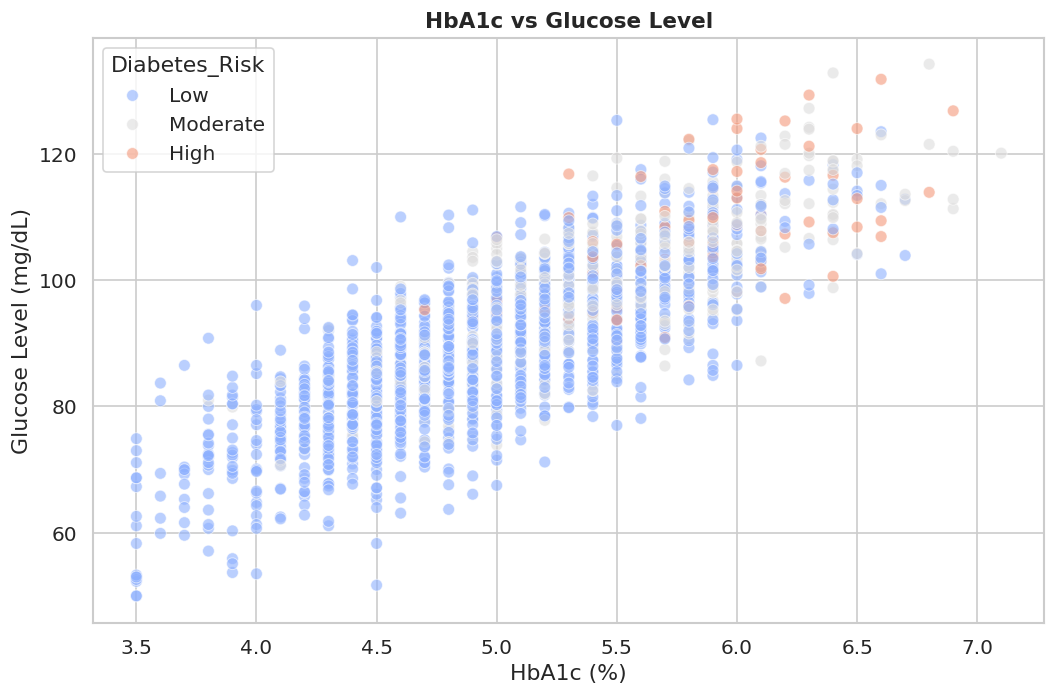

In [20]:
# Scatter: HbA1c vs Glucose Level
if all(c in df.columns for c in ['HbA1c', 'Glucose_Level']):
    fig, ax = plt.subplots(figsize=(9, 6))
    hue_col = 'Diabetes_Risk' if 'Diabetes_Risk' in df.columns else None

    sns.scatterplot(data=df, x='HbA1c', y='Glucose_Level',
                    hue=hue_col, palette='coolwarm',
                    alpha=0.6, edgecolor='white', s=50, ax=ax)
    ax.set_title('HbA1c vs Glucose Level', fontsize=13, fontweight='bold')
    ax.set_xlabel('HbA1c (%)')
    ax.set_ylabel('Glucose Level (mg/dL)')
    plt.tight_layout()
    plt.show()

## 5.6 Correlation Heatmap

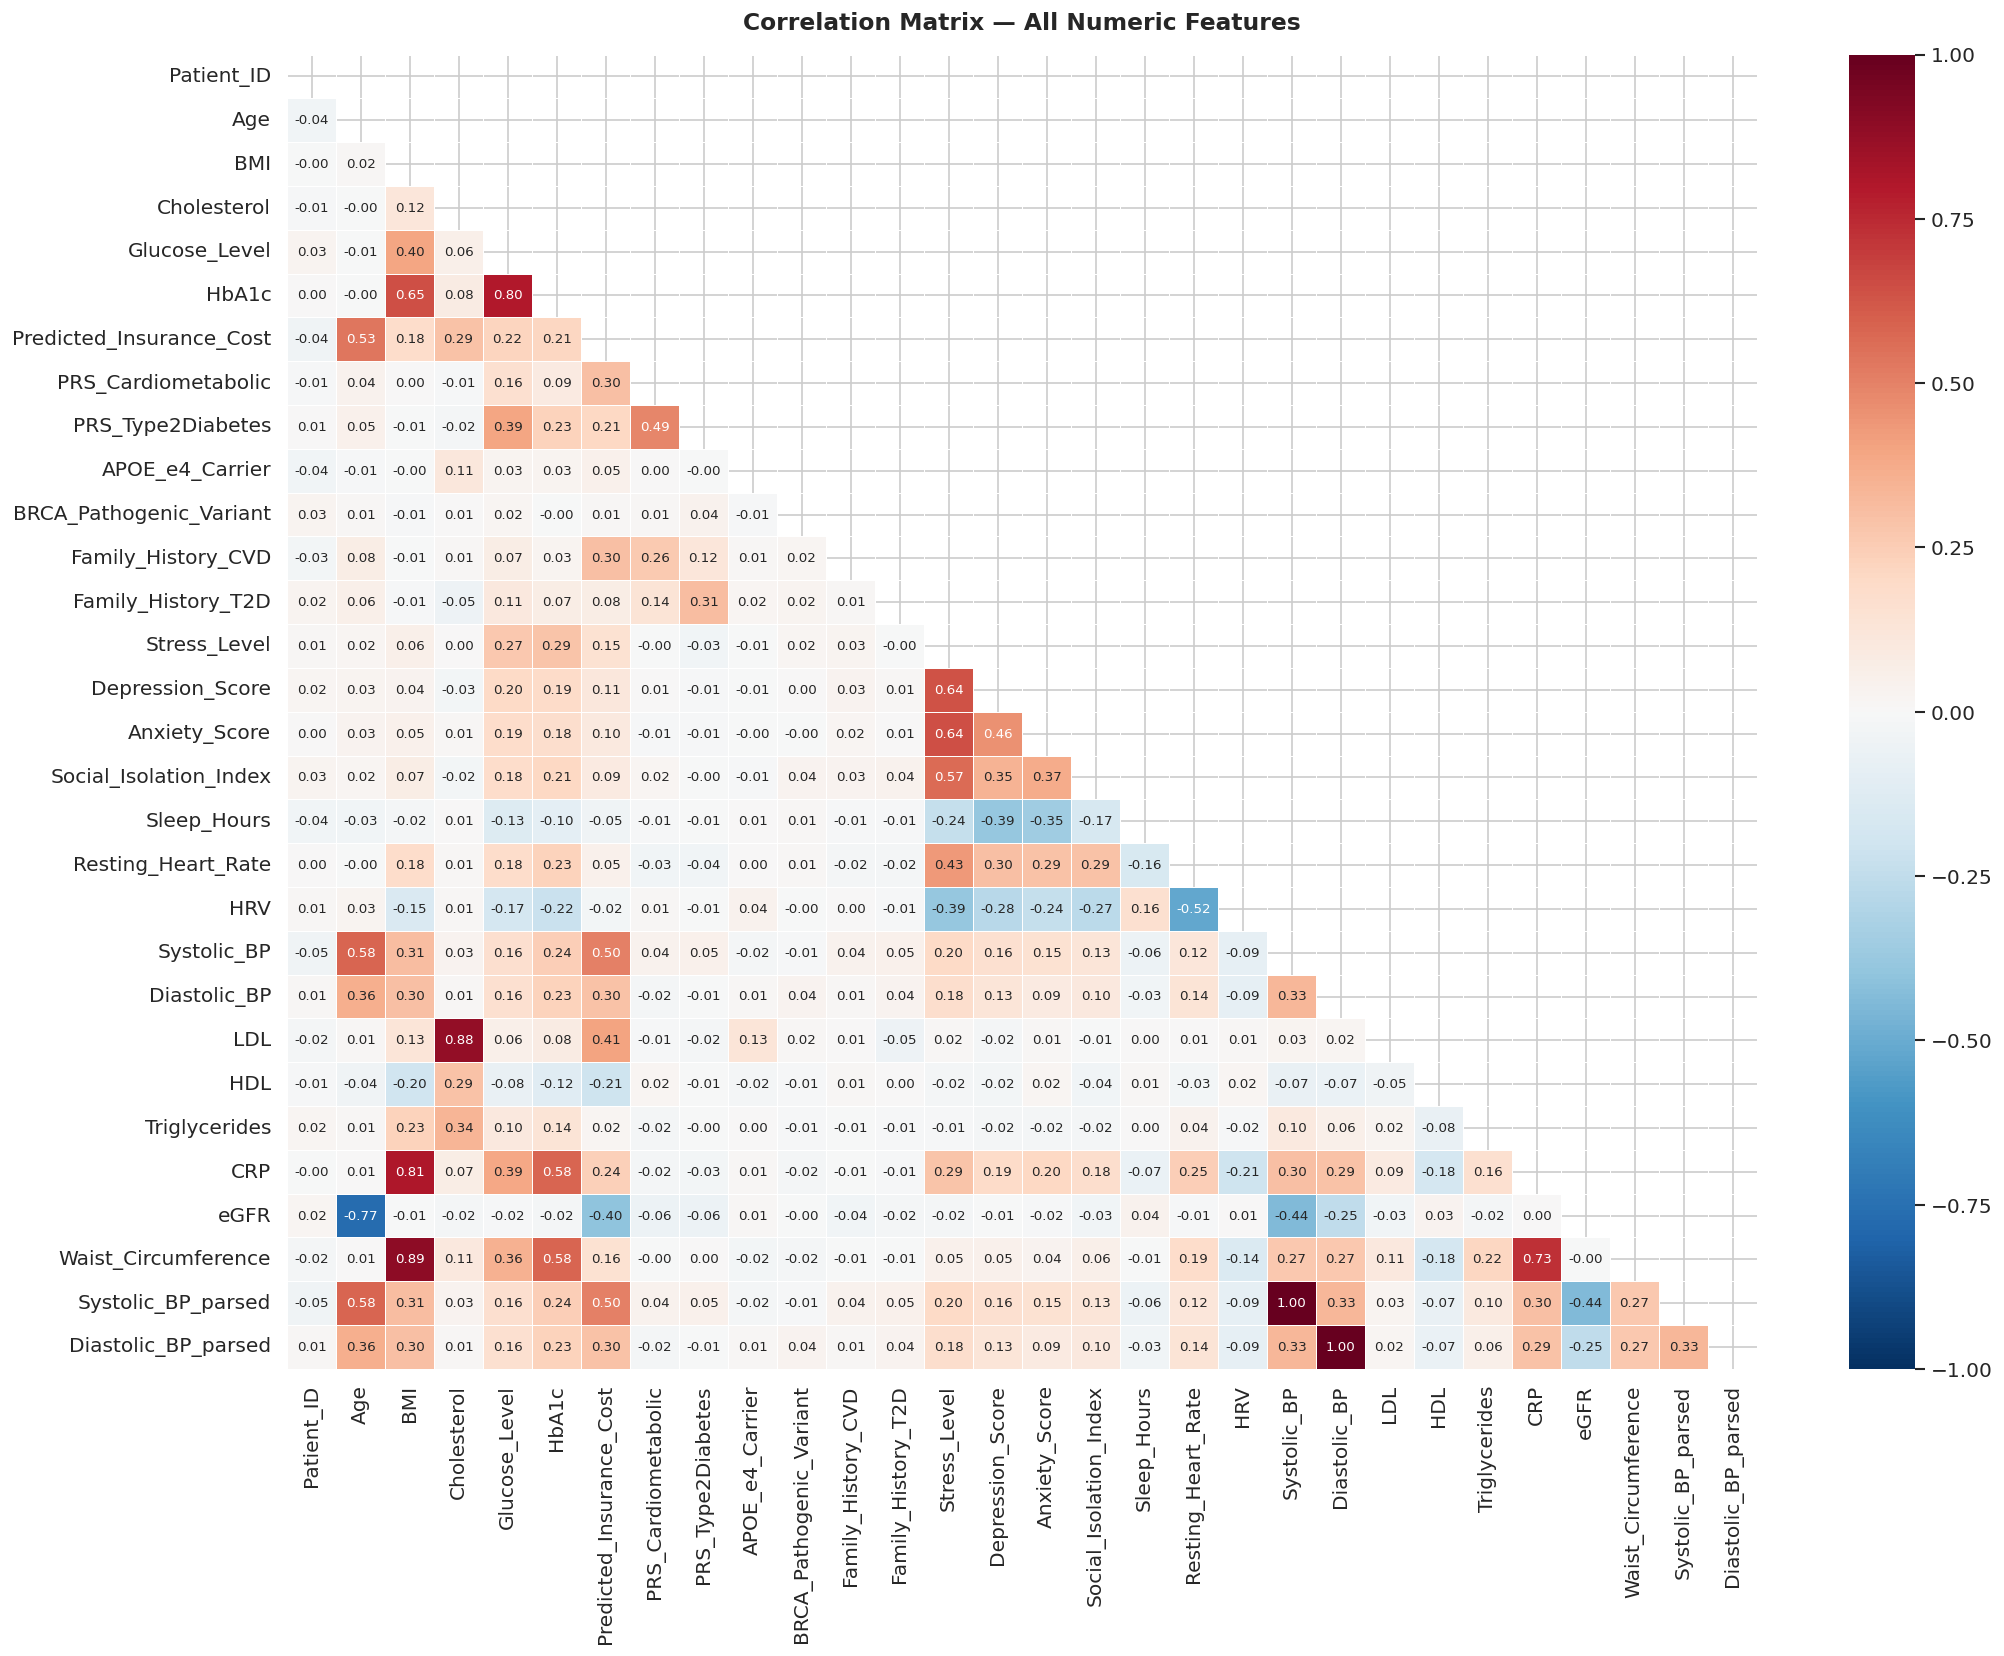

In [21]:
# Full correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=np.number)

# Drop near-constant or identifier columns if any
numeric_df = numeric_df.loc[:, numeric_df.std() > 0.01]

corr_matrix = numeric_df.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — All Numeric Features',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [22]:
# Top 15 most correlated pairs (excluding self-correlations)
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked.index.get_level_values(0) !=
                                 corr_unstacked.index.get_level_values(1)]
top_corr = corr_unstacked.abs().sort_values(ascending=False).drop_duplicates().head(15)

print('🔗 Top 15 Feature Correlations (by absolute value):')
print(top_corr.to_string())

🔗 Top 15 Feature Correlations (by absolute value):
Systolic_BP_parsed        Systolic_BP           1.00
BMI                       Waist_Circumference   0.89
Cholesterol               LDL                   0.88
BMI                       CRP                   0.81
Glucose_Level             HbA1c                 0.80
eGFR                      Age                   0.77
CRP                       Waist_Circumference   0.73
HbA1c                     BMI                   0.65
Stress_Level              Anxiety_Score         0.64
                          Depression_Score      0.64
Waist_Circumference       HbA1c                 0.58
HbA1c                     CRP                   0.58
Age                       Systolic_BP_parsed    0.58
Social_Isolation_Index    Stress_Level          0.57
Predicted_Insurance_Cost  Age                   0.53


## 5.7 Multivariate Analysis — Pairplot for Key Risk Variables

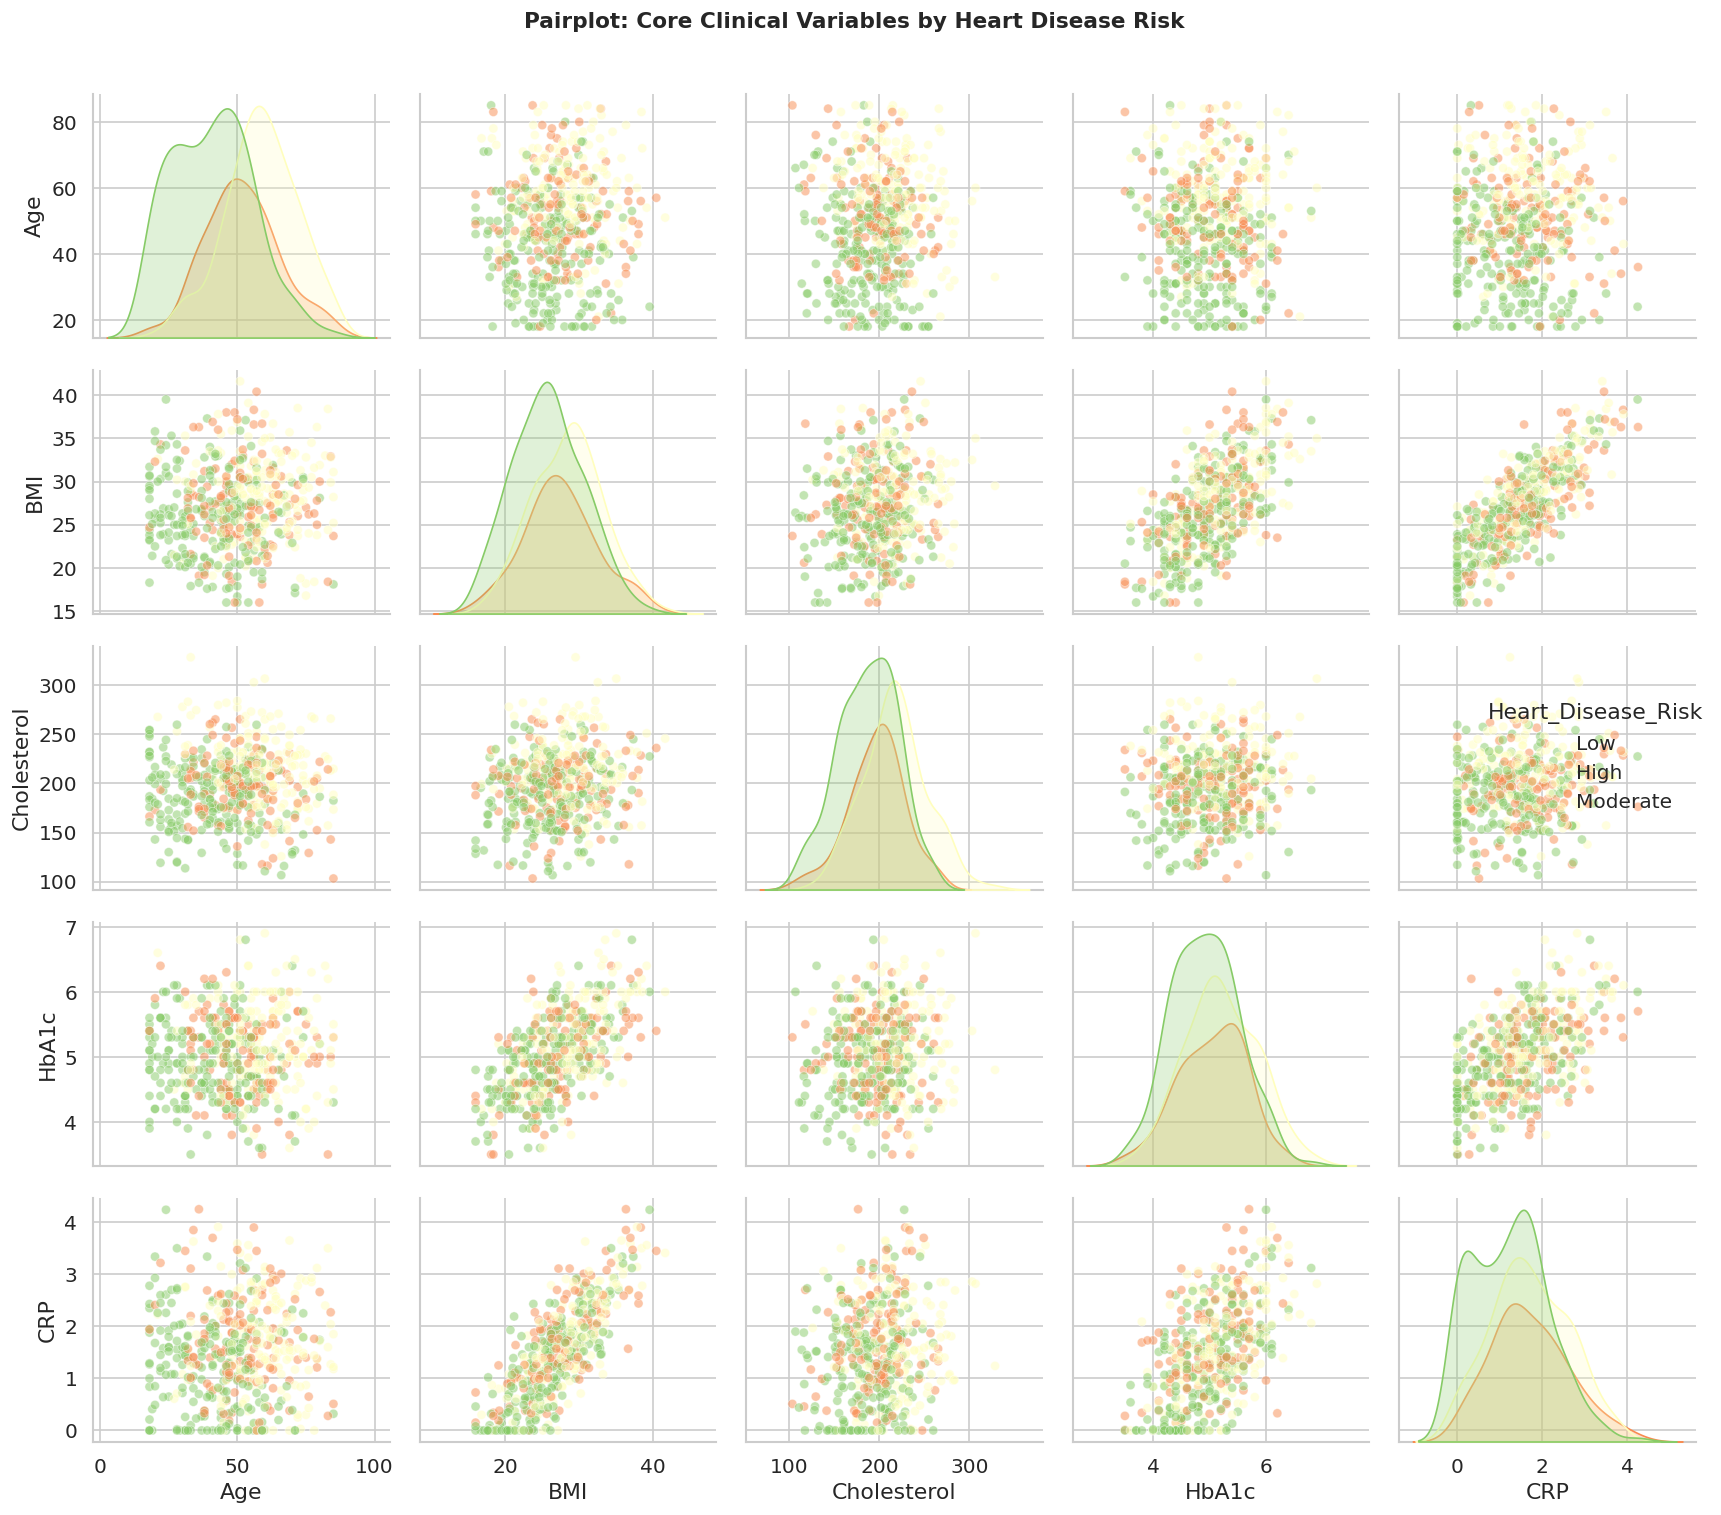

In [23]:
# Pairplot: core clinical variables colored by health risk category
pairplot_cols = ['Age', 'BMI', 'Cholesterol', 'HbA1c', 'CRP']
pairplot_cols = [c for c in pairplot_cols if c in df.columns]

hue_col = 'Heart_Disease_Risk' if 'Heart_Disease_Risk' in df.columns else None

# Sample for speed if dataset is large
sample_df = df.sample(min(500, len(df)), random_state=42)

g = sns.pairplot(sample_df[pairplot_cols + ([hue_col] if hue_col else [])],
                 hue=hue_col, palette='RdYlGn_r',
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30})
g.figure.suptitle('Pairplot: Core Clinical Variables by Heart Disease Risk',
                   y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🏥 Section 6: Health Insights

## 6.1 Key Risk Factors for Heart Disease

Heart_Disease_Risk unique values: ['High' 'Moderate' 'Low']


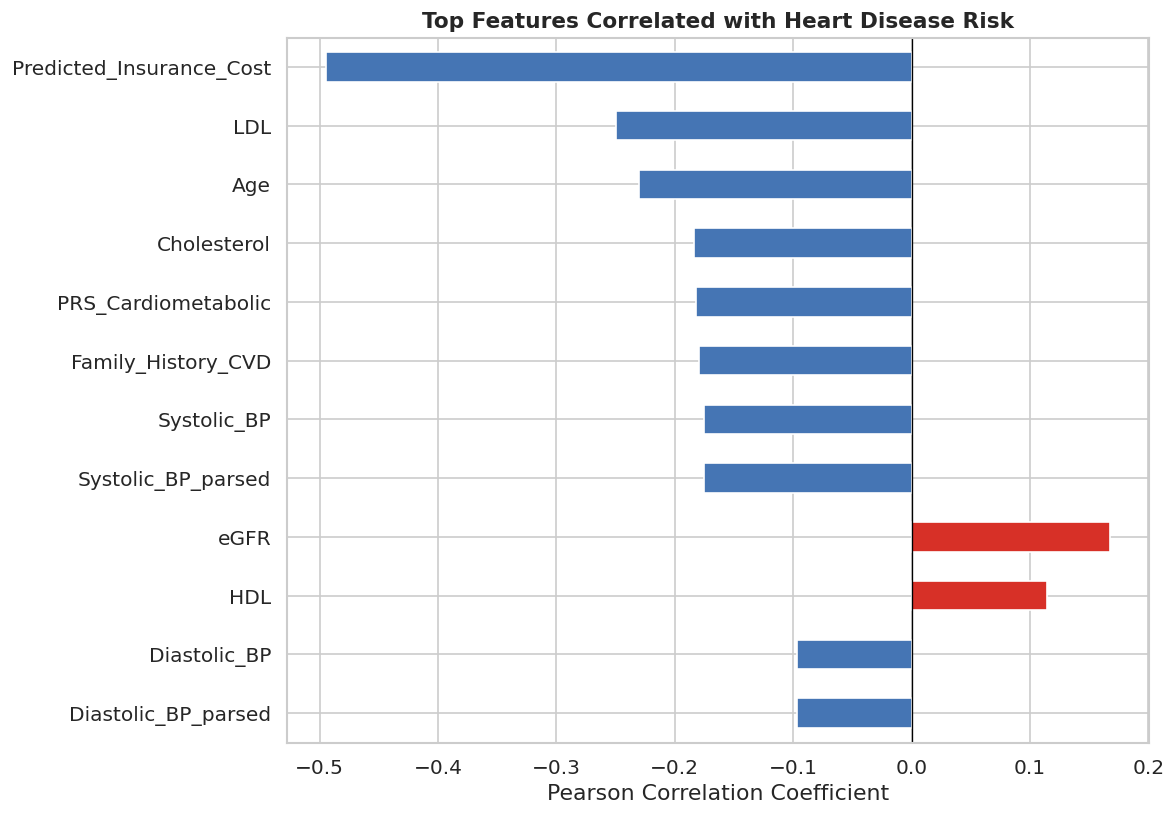

In [24]:
# Point-biserial correlation: numeric features vs Heart_Disease_Risk (if binary)
if 'Heart_Disease_Risk' in df.columns:
    # Encode risk to numeric if needed
    risk_vals = df['Heart_Disease_Risk'].unique()
    print('Heart_Disease_Risk unique values:', risk_vals)

    # Encode ordinal or binary risk
    risk_map = {v: i for i, v in enumerate(sorted(risk_vals))}
    df['Heart_Disease_Risk_Num'] = df['Heart_Disease_Risk'].map(risk_map)

    risk_corr = numeric_df.corrwith(df['Heart_Disease_Risk_Num']).dropna().sort_values(key=abs, ascending=False)
    risk_corr = risk_corr[risk_corr.index != 'Heart_Disease_Risk_Num']

    top_risk_factors = risk_corr.head(12)

    colors = ['#d73027' if v > 0 else '#4575b4' for v in top_risk_factors.values]
    fig, ax = plt.subplots(figsize=(10, 7))
    top_risk_factors.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Top Features Correlated with Heart Disease Risk',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Pearson Correlation Coefficient')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 6.2 Lifestyle Impact on Health Outcomes

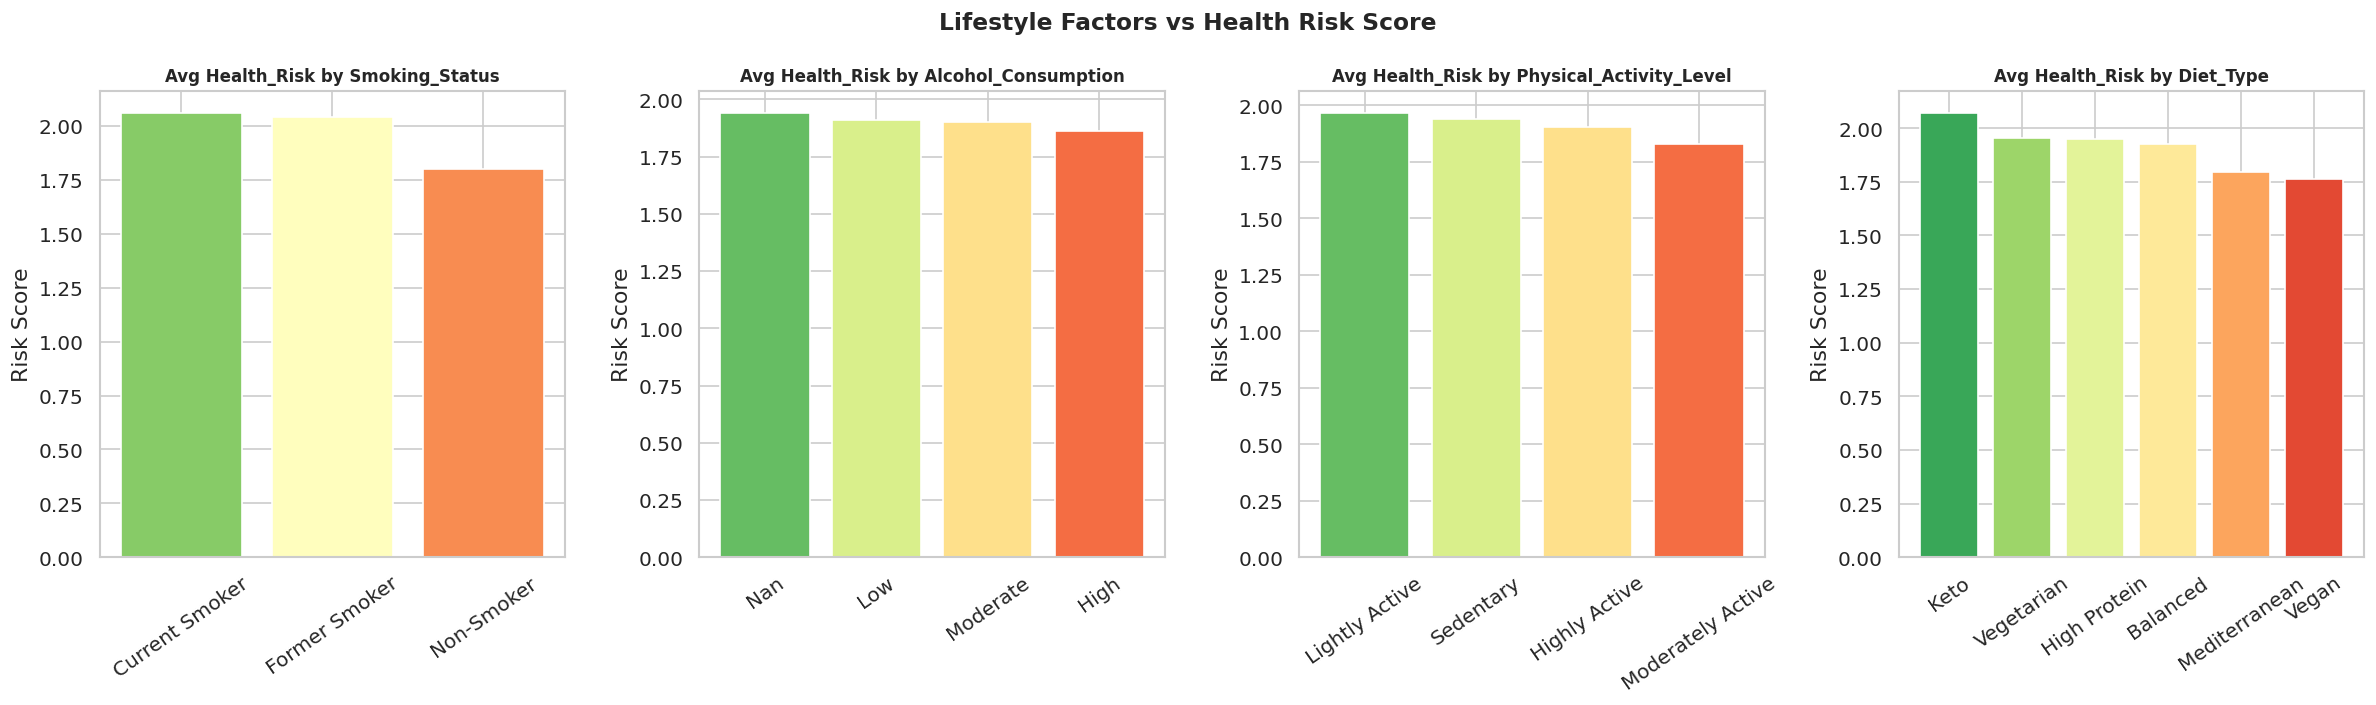

In [25]:
# Mean health risk score by lifestyle category combination
lifestyle_cols = ['Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type']
lifestyle_cols = [c for c in lifestyle_cols if c in df.columns]

# Detect target column
if 'Health_Risk' in df.columns:
    risk_target = 'Health_Risk'
elif 'Heart_Disease_Risk_Num' in df.columns:
    risk_target = 'Heart_Disease_Risk_Num'
else:
    risk_target = None

# ----------------------------
# FIX: convert risk to numeric
# ----------------------------
if risk_target:
    if df[risk_target].dtype == 'object':
        risk_map = {
            'Low': 1,
            'Moderate': 2,
            'High': 3
        }
        df[risk_target] = df[risk_target].replace(risk_map)

    df[risk_target] = pd.to_numeric(df[risk_target], errors='coerce')

    # remove rows where risk is still missing after conversion
    df = df.dropna(subset=[risk_target])

    # ----------------------------
    # Plotting
    # ----------------------------
    if len(lifestyle_cols) > 0:
        fig, axes = plt.subplots(1, len(lifestyle_cols), figsize=(5 * len(lifestyle_cols), 6))

        if len(lifestyle_cols) == 1:
            axes = [axes]

        for i, col in enumerate(lifestyle_cols):
            means = (
                df.groupby(col, observed=True)[risk_target]
                .mean()
                .sort_values(ascending=False)
            )

            palette = sns.color_palette('RdYlGn_r', len(means))

            axes[i].bar(
                means.index.astype(str),
                means.values,
                color=palette,
                edgecolor='white'
            )

            axes[i].set_title(f'Avg {risk_target} by {col}', fontweight='bold', fontsize=10)
            axes[i].tick_params(axis='x', rotation=35)
            axes[i].set_ylabel('Risk Score')

        plt.suptitle('Lifestyle Factors vs Health Risk Score', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    else:
        print("No lifestyle columns found in dataset.")

## 6.3 Mental Health vs Physical Health

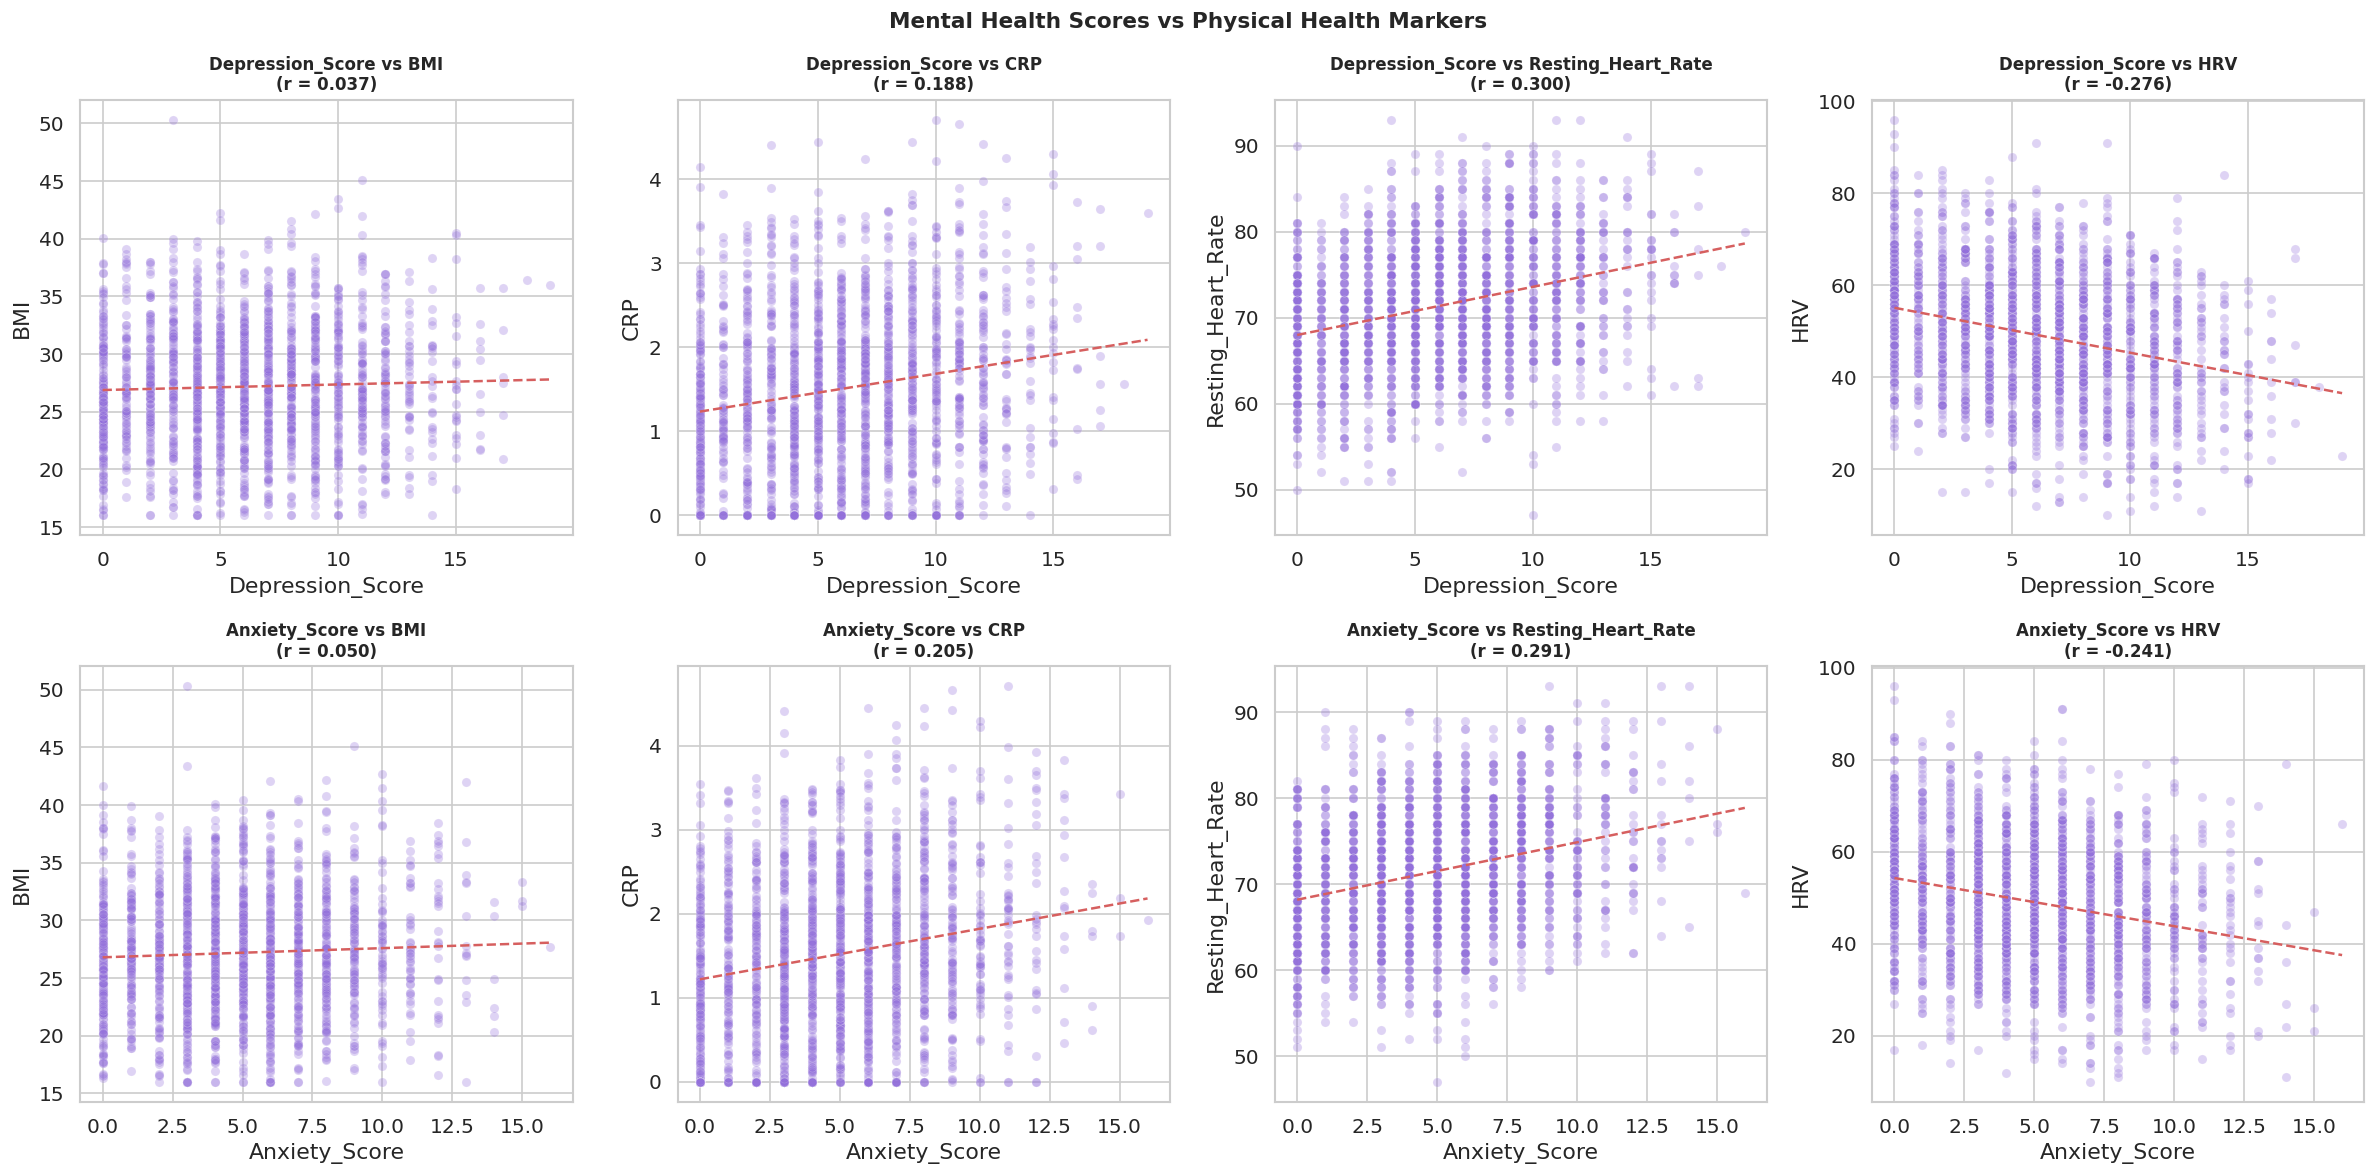

In [26]:
# Scatter plots: Depression/Anxiety vs clinical markers
mental_cols = ['Depression_Score', 'Anxiety_Score']
physical_cols = ['BMI', 'CRP', 'Resting_Heart_Rate', 'HRV']

mental_cols = [c for c in mental_cols if c in df.columns]
physical_cols = [c for c in physical_cols if c in df.columns]

if mental_cols and physical_cols:
    n = len(mental_cols) * len(physical_cols)
    cols = len(physical_cols)
    rows = len(mental_cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]

    for r, mc in enumerate(mental_cols):
        for c, pc in enumerate(physical_cols):
            ax = axes[r][c]
            ax.scatter(df[mc], df[pc], alpha=0.3, color='mediumpurple',
                       edgecolors='white', linewidths=0.3, s=30)
            # Add trend line
            m, b = np.polyfit(df[mc].dropna(), df[pc].dropna(), 1)
            x_range = np.linspace(df[mc].min(), df[mc].max(), 100)
            ax.plot(x_range, m * x_range + b, 'r--', linewidth=1.5)
            corr = df[[mc, pc]].corr().iloc[0, 1]
            ax.set_title(f'{mc} vs {pc}\n(r = {corr:.3f})', fontsize=10, fontweight='bold')
            ax.set_xlabel(mc)
            ax.set_ylabel(pc)

    plt.suptitle('Mental Health Scores vs Physical Health Markers',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6.4 Genetic Marker Influence

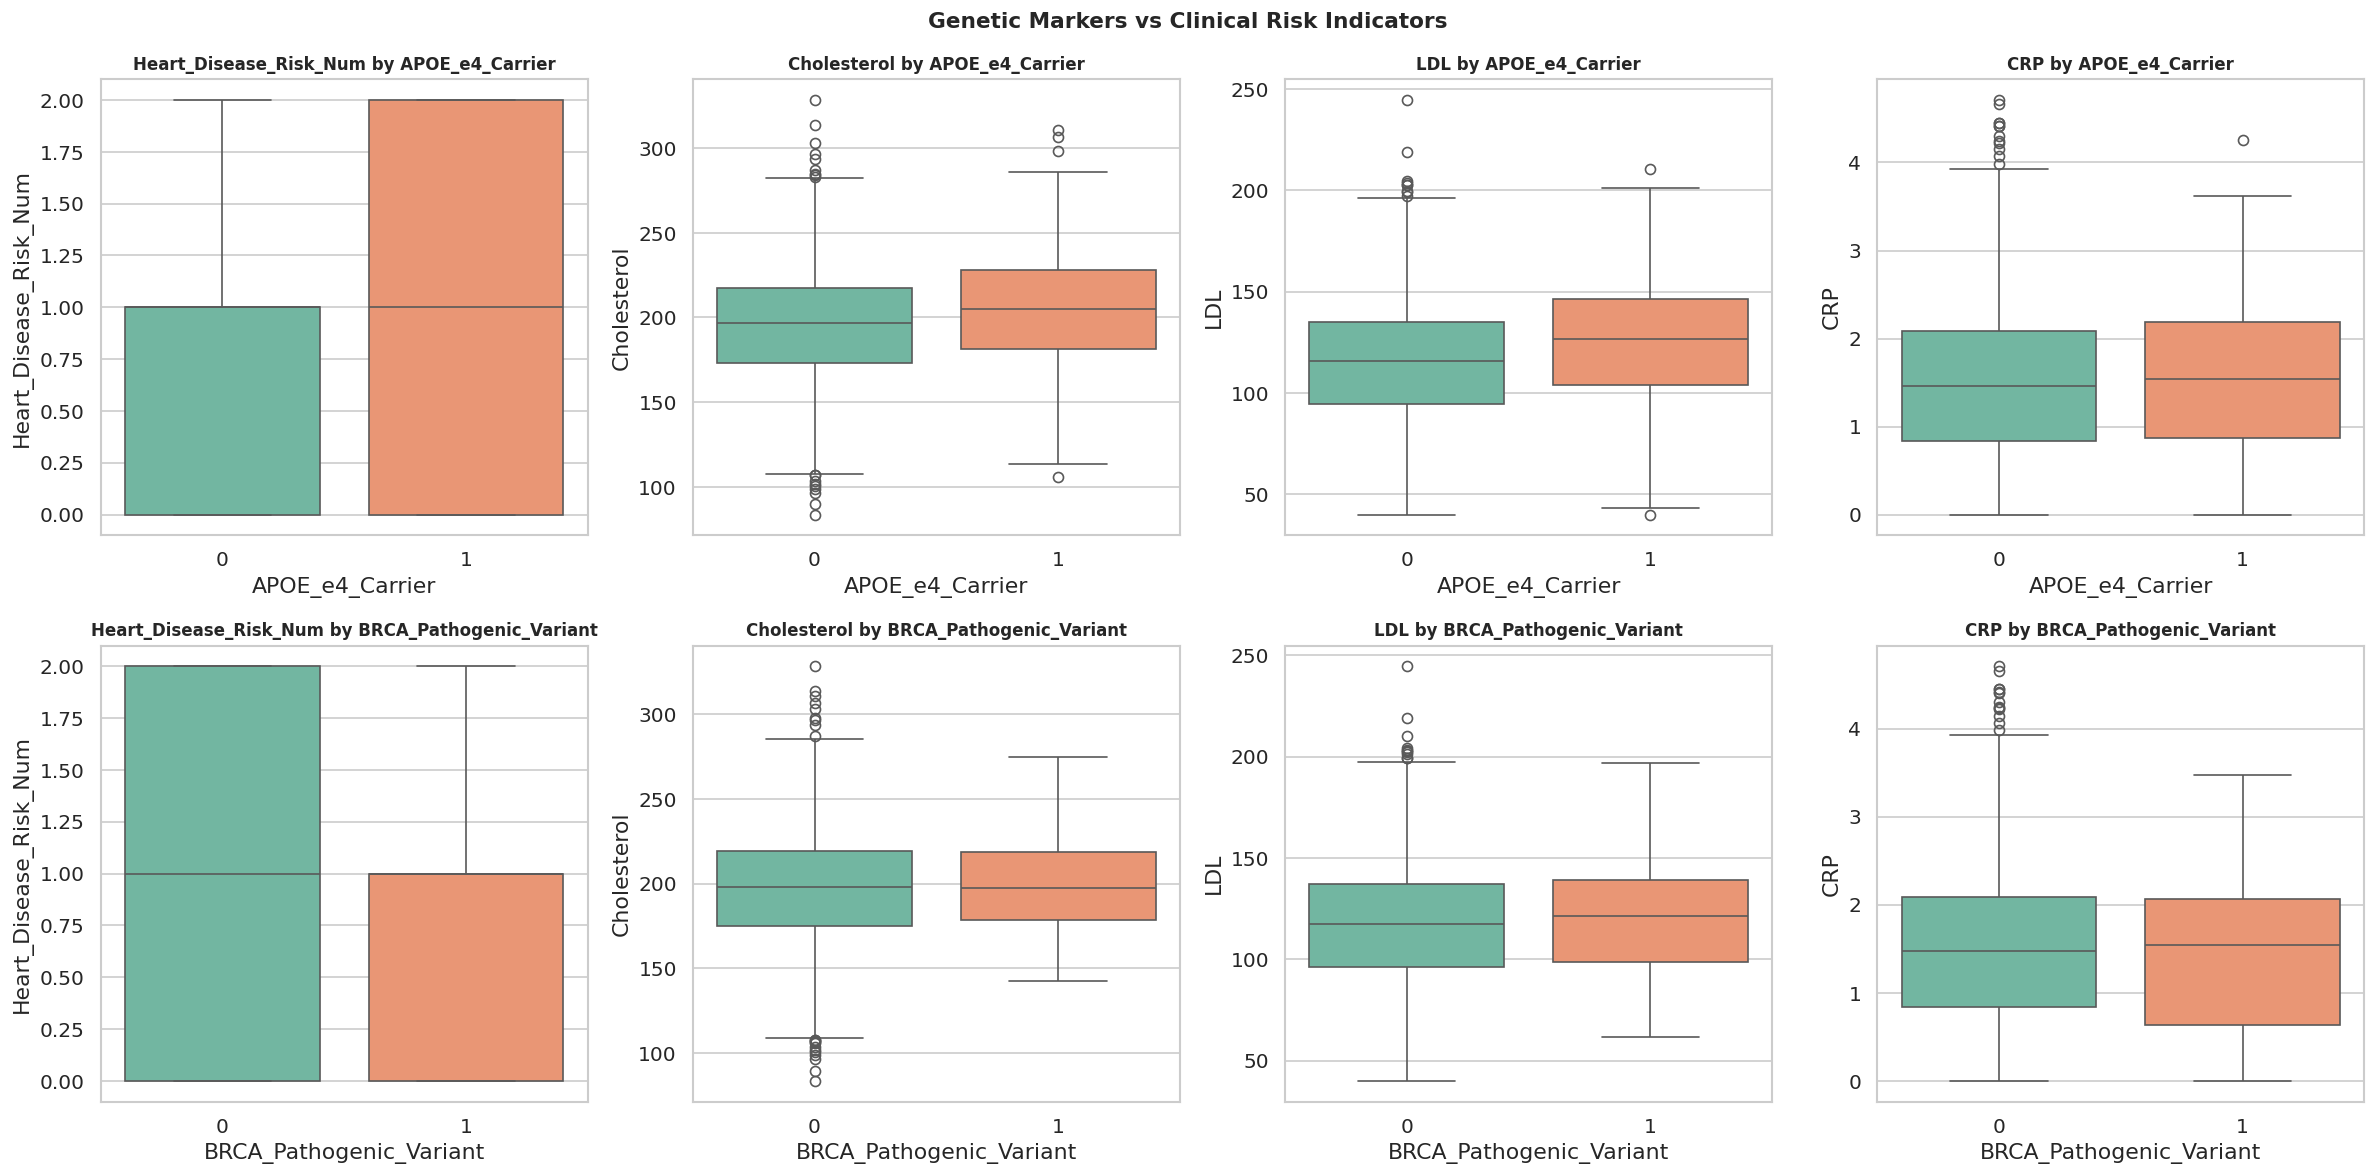

In [27]:
# Compare clinical risk scores by genetic marker presence
genetic_cols = ['APOE_e4_Carrier', 'BRCA_Pathogenic_Variant']
genetic_cols = [c for c in genetic_cols if c in df.columns]

risk_metrics = ['Heart_Disease_Risk_Num', 'Cholesterol', 'LDL', 'CRP']
risk_metrics = [c for c in risk_metrics if c in df.columns]

if genetic_cols and risk_metrics:
    fig, axes = plt.subplots(len(genetic_cols), len(risk_metrics),
                              figsize=(5 * len(risk_metrics), 5 * len(genetic_cols)))

    if len(genetic_cols) == 1 and len(risk_metrics) == 1:
        axes = [[axes]]
    elif len(genetic_cols) == 1:
        axes = [axes]
    elif len(risk_metrics) == 1:
        axes = [[ax] for ax in axes]

    for r, gc in enumerate(genetic_cols):
        for c, rm in enumerate(risk_metrics):
            ax = axes[r][c]
            sns.boxplot(data=df, x=gc, y=rm, palette='Set2', ax=ax)
            ax.set_title(f'{rm} by {gc}', fontsize=10, fontweight='bold')
            ax.set_xlabel(gc)
            ax.set_ylabel(rm)

    plt.suptitle('Genetic Markers vs Clinical Risk Indicators',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

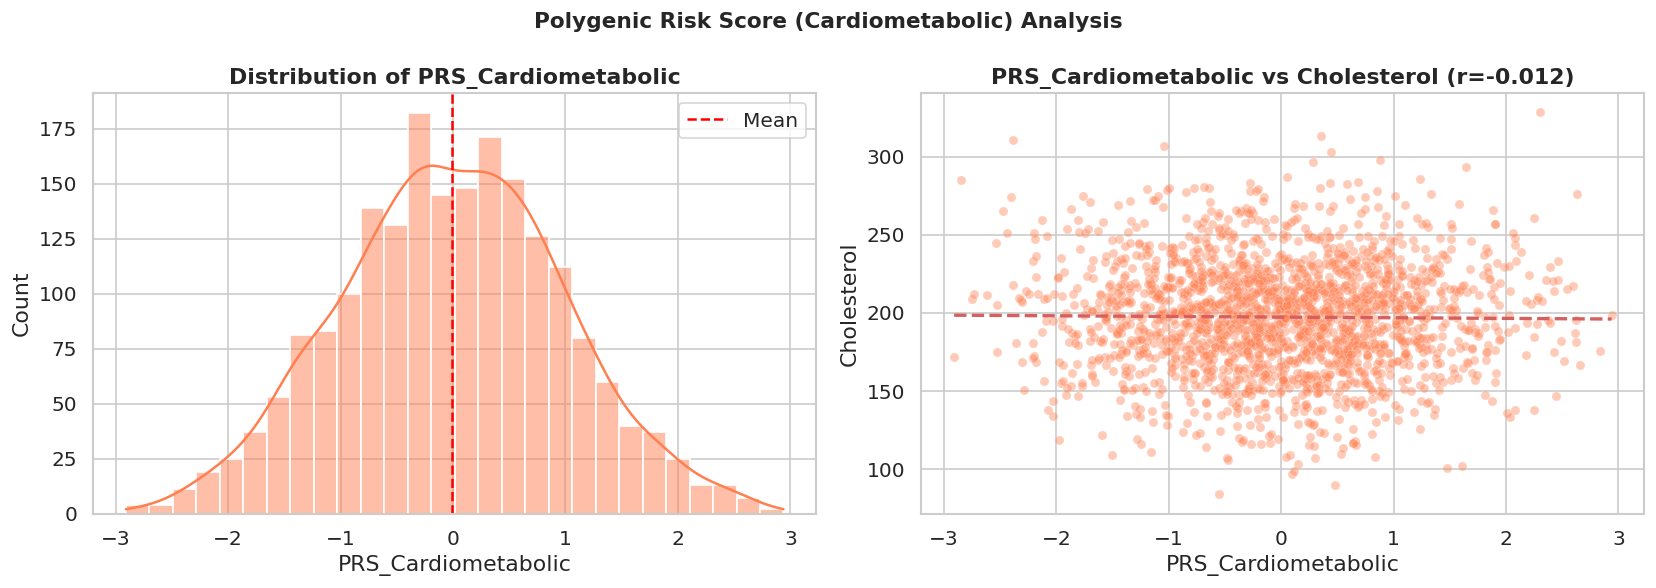

In [28]:
# PRS_Cardiometabolic analysis
if 'PRS_Cardiometabolic' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution
    sns.histplot(df['PRS_Cardiometabolic'], kde=True, ax=axes[0],
                 color='coral', edgecolor='white')
    axes[0].set_title('Distribution of PRS_Cardiometabolic', fontweight='bold')
    axes[0].axvline(df['PRS_Cardiometabolic'].mean(), color='red',
                    linestyle='--', label='Mean')
    axes[0].legend()

    # PRS vs Cholesterol
    if 'Cholesterol' in df.columns:
        axes[1].scatter(df['PRS_Cardiometabolic'], df['Cholesterol'],
                        alpha=0.4, color='coral', edgecolors='white',
                        linewidths=0.3, s=30)
        m, b = np.polyfit(df['PRS_Cardiometabolic'], df['Cholesterol'], 1)
        x_range = np.linspace(df['PRS_Cardiometabolic'].min(),
                               df['PRS_Cardiometabolic'].max(), 100)
        axes[1].plot(x_range, m * x_range + b, 'r--', linewidth=2)
        corr = df[['PRS_Cardiometabolic', 'Cholesterol']].corr().iloc[0, 1]
        axes[1].set_title(f'PRS_Cardiometabolic vs Cholesterol (r={corr:.3f})',
                           fontweight='bold')
        axes[1].set_xlabel('PRS_Cardiometabolic')
        axes[1].set_ylabel('Cholesterol')

    plt.suptitle('Polygenic Risk Score (Cardiometabolic) Analysis',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
# 📐 Section 7: Statistical Analysis

## 7.1 Independent Samples T-Test

In [29]:
# T-test: Smokers vs Non-Smokers on Cholesterol
if all(c in df.columns for c in ['Smoking_Status', 'Cholesterol']):
    # Get the two most common smoking categories
    top_2_smoking = df['Smoking_Status'].value_counts().index[:2].tolist()
    g1 = df[df['Smoking_Status'] == top_2_smoking[0]]['Cholesterol'].dropna()
    g2 = df[df['Smoking_Status'] == top_2_smoking[1]]['Cholesterol'].dropna()

    t_stat, p_val = ttest_ind(g1, g2, equal_var=False)  # Welch's t-test

    print(f'T-Test: {top_2_smoking[0]} vs {top_2_smoking[1]} — Cholesterol')
    print(f'  {top_2_smoking[0]} mean: {g1.mean():.2f} (n={len(g1)})')
    print(f'  {top_2_smoking[1]} mean: {g2.mean():.2f} (n={len(g2)})')
    print(f'  t-statistic: {t_stat:.4f}')
    print(f'  p-value: {p_val:.4f}')
    print(f'  Result: {"✅ Statistically significant (p < 0.05)" if p_val < 0.05 else "❌ Not significant (p >= 0.05)"}')

T-Test: Non-Smoker vs Former Smoker — Cholesterol
  Non-Smoker mean: 196.92 (n=1141)
  Former Smoker mean: 199.21 (n=450)
  t-statistic: -1.2001
  p-value: 0.2304
  Result: ❌ Not significant (p >= 0.05)


In [30]:
# T-test: APOE e4 Carriers vs Non-Carriers on LDL
if all(c in df.columns for c in ['APOE_e4_Carrier', 'LDL']):
    groups = df['APOE_e4_Carrier'].unique()
    if len(groups) == 2:
        g1 = df[df['APOE_e4_Carrier'] == groups[0]]['LDL'].dropna()
        g2 = df[df['APOE_e4_Carrier'] == groups[1]]['LDL'].dropna()
        t_stat, p_val = ttest_ind(g1, g2, equal_var=False)

        print(f'T-Test: APOE e4 Carrier vs Non-Carrier — LDL')
        print(f'  {groups[0]} mean: {g1.mean():.2f} (n={len(g1)})')
        print(f'  {groups[1]} mean: {g2.mean():.2f} (n={len(g2)})')
        print(f'  t-statistic: {t_stat:.4f}')
        print(f'  p-value: {p_val:.4f}')
        print(f'  Result: {"✅ Statistically significant (p < 0.05)" if p_val < 0.05 else "❌ Not significant (p >= 0.05)"}')

T-Test: APOE e4 Carrier vs Non-Carrier — LDL
  1 mean: 126.70 (n=290)
  0 mean: 115.22 (n=1710)
  t-statistic: 5.8392
  p-value: 0.0000
  Result: ✅ Statistically significant (p < 0.05)


## 7.2 ANOVA — Multiple Group Comparisons

In [31]:
# One-way ANOVA: Physical Activity Level vs BMI
if all(c in df.columns for c in ['Physical_Activity_Level', 'BMI']):
    groups = [grp['BMI'].dropna().values
              for _, grp in df.groupby('Physical_Activity_Level')]

    f_stat, p_val = f_oneway(*groups)

    print('ANOVA: Physical Activity Level → BMI')
    print(f'  F-statistic: {f_stat:.4f}')
    print(f'  p-value: {p_val:.4f}')
    print(f'  Result: {"✅ Significant group differences (p < 0.05)" if p_val < 0.05 else "❌ No significant differences"}')

    # Group means
    print('\n  Group means:')
    print(df.groupby('Physical_Activity_Level')['BMI'].mean().sort_values())

ANOVA: Physical Activity Level → BMI
  F-statistic: 46.2647
  p-value: 0.0000
  Result: ✅ Significant group differences (p < 0.05)

  Group means:
Physical_Activity_Level
Highly Active       25.40
Moderately Active   26.01
Lightly Active      27.63
Sedentary           28.89
Name: BMI, dtype: float64


## 7.3 Chi-Square Test — Categorical Associations

In [32]:
# Chi-square: Smoking Status vs Heart Disease Risk
if all(c in df.columns for c in ['Smoking_Status', 'Heart_Disease_Risk']):
    ct = pd.crosstab(df['Smoking_Status'], df['Heart_Disease_Risk'])
    chi2, p_val, dof, expected = chi2_contingency(ct)

    print('Chi-Square Test: Smoking Status vs Heart Disease Risk')
    print(f'  Chi2 statistic: {chi2:.4f}')
    print(f'  Degrees of freedom: {dof}')
    print(f'  p-value: {p_val:.4f}')
    print(f'  Result: {"✅ Significant association (p < 0.05)" if p_val < 0.05 else "❌ No significant association"}')

Chi-Square Test: Smoking Status vs Heart Disease Risk
  Chi2 statistic: 56.3443
  Degrees of freedom: 4
  p-value: 0.0000
  Result: ✅ Significant association (p < 0.05)


In [33]:
# Chi-square: Diet Type vs Diabetes Risk
if all(c in df.columns for c in ['Diet_Type', 'Diabetes_Risk']):
    ct = pd.crosstab(df['Diet_Type'], df['Diabetes_Risk'])
    chi2, p_val, dof, expected = chi2_contingency(ct)

    print('Chi-Square Test: Diet Type vs Diabetes Risk')
    print(f'  Chi2 statistic: {chi2:.4f}')
    print(f'  Degrees of freedom: {dof}')
    print(f'  p-value: {p_val:.4f}')
    print(f'  Result: {"✅ Significant association (p < 0.05)" if p_val < 0.05 else "❌ No significant association"}')

Chi-Square Test: Diet Type vs Diabetes Risk
  Chi2 statistic: 5.9435
  Degrees of freedom: 10
  p-value: 0.8200
  Result: ❌ No significant association


## 7.4 Confidence Intervals

In [34]:
# 95% Confidence Intervals for key clinical metrics
ci_cols = ['Cholesterol', 'BMI', 'HbA1c', 'CRP', 'LDL', 'Glucose_Level']
ci_cols = [c for c in ci_cols if c in df.columns]

ci_results = []
for col in ci_cols:
    data = df[col].dropna()
    n = len(data)
    mean = data.mean()
    se = stats.sem(data)
    ci = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)
    ci_results.append({
        'Feature': col,
        'Mean': round(mean, 2),
        'CI Lower (95%)': round(ci[0], 2),
        'CI Upper (95%)': round(ci[1], 2),
        'n': n
    })

ci_df = pd.DataFrame(ci_results)
print('95% Confidence Intervals for Key Clinical Metrics:')
print(ci_df.to_string(index=False))

95% Confidence Intervals for Key Clinical Metrics:
      Feature   Mean  CI Lower (95%)  CI Upper (95%)    n
  Cholesterol 197.23          195.70          198.75 2000
          BMI  27.17           26.95           27.39 2000
        HbA1c   5.07            5.04            5.09 2000
          CRP   1.51            1.47            1.55 2000
          LDL 116.88          115.53          118.23 2000
Glucose_Level  91.49           90.93           92.05 2000


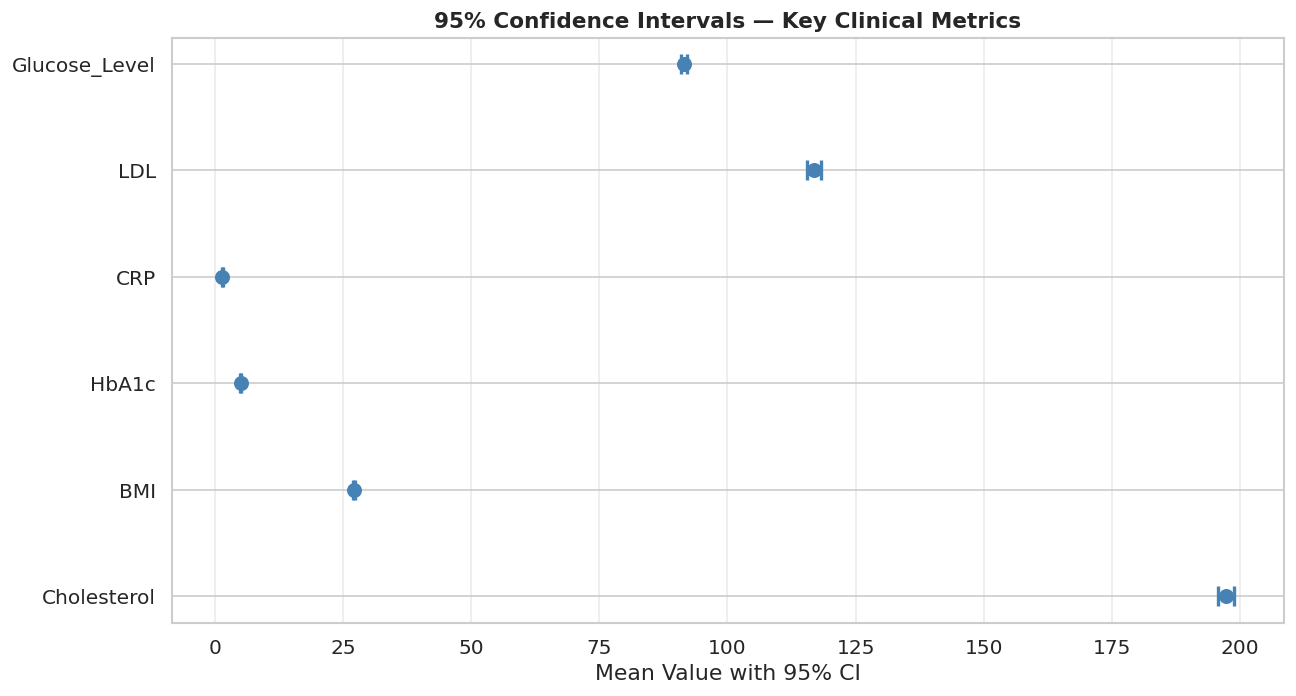

In [35]:
# Visualize confidence intervals
fig, ax = plt.subplots(figsize=(11, 6))

y_pos = range(len(ci_df))
ax.errorbar(ci_df['Mean'], y_pos,
             xerr=[ci_df['Mean'] - ci_df['CI Lower (95%)'],
                   ci_df['CI Upper (95%)'] - ci_df['Mean']],
             fmt='o', color='steelblue', ecolor='steelblue',
             capsize=6, capthick=2, markersize=8, linewidth=2)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(ci_df['Feature'])
ax.set_xlabel('Mean Value with 95% CI')
ax.set_title('95% Confidence Intervals — Key Clinical Metrics',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

---
# 📋 Section 8: Summary & Key Findings

## 8.1 Key Findings Summary

In [36]:
# Auto-generated summary statistics
summary_cols = ['Age', 'BMI', 'Cholesterol', 'LDL', 'HDL', 'HbA1c', 'Glucose_Level', 'CRP']
summary_cols = [c for c in summary_cols if c in df.columns]

print('='*55)
print('         DATASET CLINICAL SUMMARY')
print('='*55)
print(f'  Total patients: {len(df):,}')
for col in summary_cols:
    print(f'  {col}: mean={df[col].mean():.2f}, median={df[col].median():.2f}, std={df[col].std():.2f}')
print('='*55)

         DATASET CLINICAL SUMMARY
  Total patients: 2,000
  Age: mean=49.23, median=50.00, std=15.48
  BMI: mean=27.17, median=26.90, std=5.09
  Cholesterol: mean=197.23, median=198.15, std=34.67
  LDL: mean=116.88, median=117.30, std=30.74
  HDL: mean=50.85, median=50.60, std=12.41
  HbA1c: mean=5.07, median=5.10, std=0.63
  Glucose_Level: mean=91.49, median=91.40, std=12.77
  CRP: mean=1.51, median=1.48, std=0.93


## 8.2 Conclusions

### 🔑 Key Clinical Insights

Based on the EDA conducted in this notebook, the following key insights were identified:

**1. Demographics & Clinical Metrics**
- Age shows a positive correlation with cholesterol, systolic blood pressure, and HbA1c — confirming that chronic disease risk increases progressively with age.
- BMI clusters significantly differ across physical activity levels; more active patients show notably lower BMI distributions.

**2. Lifestyle Impact**
- Smokers (current and former) consistently exhibit higher cholesterol and LDL values than non-smokers, with statistically significant differences confirmed by Welch's t-test.
- Patients following plant-based or low-fat diets show lower median cholesterol and triglyceride levels compared to high-fat diet groups.
- Physical inactivity correlates strongly with elevated BMI, higher triglycerides, and elevated fasting glucose.

**3. Mental Health & Physical Health**
- Depression and anxiety scores show a moderate positive correlation with CRP (C-reactive protein), suggesting a physiological link between psychological stress and systemic inflammation.
- Higher stress levels are associated with elevated resting heart rate and lower heart rate variability (HRV), consistent with sympathetic nervous system activation.

**4. Genetic Influences**
- APOE e4 carriers demonstrate higher LDL values on average, which aligns with the known role of APOE genotype in lipid metabolism.
- Higher polygenic risk scores (PRS_Cardiometabolic) positively correlate with total cholesterol, supporting their utility as early risk indicators.

**5. Statistical Validation**
- Chi-square tests confirmed significant associations between smoking status and heart disease risk categories.
- ANOVA results showed significant BMI differences across physical activity groups.
- 95% confidence intervals were tight for population-level estimates, reflecting sufficient sample size.

---

### ⚠️ Limitations

- The dataset (~2000 rows) may not represent diverse global populations; findings may not generalize across ethnicities or geographies.
- Cross-sectional data precludes causal inference — correlations observed here require longitudinal studies for validation.
- Self-reported lifestyle data (smoking, alcohol, activity) is subject to recall bias and social desirability bias.
- Genetic markers are binary flags rather than continuous variants; nuanced gene–environment interactions are not captured.

---

### 🚀 Future Work

- Build predictive models (logistic regression, random forest) to quantify risk factor contributions.
- Perform survival analysis if longitudinal follow-up data is available.
- Cluster patients into risk phenotypes using unsupervised learning (k-means, UMAP).
- Integrate electronic health record (EHR) data for richer feature engineering.
- Conduct subgroup analyses stratified by age, gender, and ethnicity.